<a href="https://colab.research.google.com/github/lphansen/RiskUncertaintyValue/blob/main/expansion_suite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncertain Expansion Example Notebook

# 1 Preliminaries <a class="anchor" id="s2"></a>

## 1.1 Model Setup
$$
\begin{align}
X_{t+1} \left( \mathsf{q} \right) =  & \hspace{.2cm} \psi^x \left[D_t \left( \mathsf{q} \right), X_{t} \left( \mathsf{q} \right), {\sf q} W_{t+1}, {\sf q} \right], \cr
\log G_{t+1} \left( \mathsf{q} \right) - \log G_t \left( \mathsf{q} \right) = & \hspace{.2cm} \psi^g \left[ D_t \left( \mathsf{q} \right), X_{t} \left( \mathsf{q},
 \right), {\sf q} W_{t+1}, {\sf q}  \right], \cr
{\widehat C}_t \left( \mathsf{q} \right)  = & \hspace{.2cm} \kappa \left[D_t \left( \mathsf{q} \right), X_{t} \left( \mathsf{q}  \right) \right] + {\widehat G}_t \left( \mathsf{q} \right), \cr
0 & = \phi[D_t({\sf q} ), X_t({\sf q})].
\end{align}
$$

In addition, there are a set of first-order conditions and co-state equations detailed in Chapter 10 of the book. These are compiled automatically by the code.


## 1.2 Inputs

The `Expansion Suite` uses the function `uncertain_expansion` to approximate a solution to the above system locally. The user must specify several sets of inputs. Define the relevant variables:

```{list-table}
* - Input
  - Description
  - Notation in text
* - `control_variables`
  - Variables chosen by the decision-maker at time $t$
  - $D_t$
* - `state_variables`
  - Variables that describe the current state of the system
  - $X_t$
* - `shock_variables`
  - Variables representing different entries of the Brownian motion variable
  - $W_t$
```

The $t+1$ variables will be automatically created from this. For example, if a state variable is inputted as `Z_t`, an additional state variable `Z_tp1` will be automatically generated. 
We also need to define the equilibrium conditions:

```{list-table}
* - Input
  - Description
  - Notation in text
* - `kappa`
  - Log share of capital not allocated to consumption
  - $\kappa(X_t(q),D_t(q))$
* - `growth`
  - Law of motion for $\hat{G}_{t+1}-\hat{G}_t$
  - $\psi^g(D_t(q),X_t(q),qW_{t+1},q)$
* - `state_equations`
  - Law of motion for state variables
  - $\psi^x(D_t(q),X_t(q),qW_{t+1},q)$
* - `static_constraints`
  - Vector of constraints applying to time $t$ variables
  - $\phi
  (D_t(q),X_t(q))$
```

The remaining equilibrium conditions will be automatically computed by the code. The user must also define a list of parameters and their corresponding values. This can be done by specifying pairs of inputs such as `beta = 0.99` or `gamma = 8` within the body of the function `create_args`. Note that for some parameters, notably `rho` and `gamma`, inputting 1 may cause divide-by-zero issues, so we recommend inputting 1.01 instead.

Note that the user must define the variables and parameters *before* defining the equations. Make sure that the **equations use the same expressions for variables and parameters** as previously defined by the user. 

The output is of class `ModelSolution`, which stores the coefficients for the linear-quadratic approximation for the jump and state variables; continuation values; consumption growth; and log change of measure, as well as the steady-state values of each variables. 


<br>

# 2 Example
We will now walk through the computation using the example from Section 10.7.1. Begin by installing the following libraries and downloading `RiskUncertaintyValue`, which contains the functions required to solve the model:


In [1]:
import os
import sys
import sympy as sp
workdir = os.getcwd()
base = workdir.split(r"\Codefiles\Chapter 10")[0]
# !git clone https://github.com/lphansen/RiskUncertaintyValue 
# workdir = os.getcwd() + '/RiskUncertaintyValue_old'             
# workdir = os.getcwd() + '/RiskUncertaintyValue_general'         
# workdir = os.getcwd() + '/RiskUncertaintyValue'            
sys.path.insert(0, workdir+'/src')                        
import numpy as np
import seaborn as sns
import autograd.numpy as anp
from scipy import optimize
import pandas as pd
import matplotlib.ticker as mticker 
import matplotlib.cm as cm
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=200)
from IPython.display import display, HTML
from BY_example_sol import disp
display(HTML("<style>.container { width:97% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy.stats import norm

from lin_quad import LinQuadVar
from lin_quad_util import E, concat, next_period, cal_E_ww, lq_sum, N_tilde_measure, E_N_tp1, log_E_exp, kron_prod, distance
from utilities import mat, vec, sym
from uncertain_expansion import uncertain_expansion, generate_symbols_and_args, compile_equations, get_parameter_value, \
    generate_ss_function, automate_step_1, change_parameter_value, approximate_fun
from elasticity import exposure_elasticity, price_elasticity

np.set_printoptions(suppress=True)
import pickle
from scipy.optimize import fsolve
# import sympy as sp

## 2.1 Parameters
Use the following function to define and set the values for your parameters.

In [2]:
def create_args():
    """
    Parameter dictionary for the quarterly calibration (ε = 0.25),
    consistent with the model used to generate the quarterly figures.
    """
    
    # ---------- Diffusion parameters (Table 1, continuous-time, annual) ----------
    # Table 1: σ_k = sqrt(12) * [0.92, 0.40, 0]
    #          σ_1 = sqrt(12) * [0, 5.7, 0]
    #          σ_2 = sqrt(12) * [0, 0, 0.00031]
    # We store exactly those continuous-time σ's here.
    sigma_k1 = 0.92    * anp.sqrt(12.0)
    sigma_k2 = 0.40    * anp.sqrt(12.0)
    sigma_k3 = 0.0

    sigma_z1 = 0.0
    sigma_z2 = 5.7     * anp.sqrt(12.0)
    sigma_z3 = 0.0

    sigma_y1 = 0.0
    sigma_y2 = 0.0
    sigma_y3 = 0.00031 * anp.sqrt(12.0)

    # ---------- Time step and preferences ----------
    # One model step = one quarter, so ε = 0.25 years.
    epsilon = 0.25                    # Δt in the discretization (years per step)

    delta   = 0.01                    # annual subjective discount rate
    beta    = anp.exp(-delta * epsilon)   # per-quarter discount factor

    # Preferences
    gamma = 8.001   # risk aversion γ
    rho   = 1.001    # ρ (intertemporal elasticity parameter)

    # ---------- Technology / adjustment-cost parameters ----------
    a      = 0.0922                # level in log(a - i), unit-free

    # Your equation is: (1/ζ) log(1 + ζ I/K).
    # We encode 1/ζ as phi_1 and ζ as phi_2:
    zeta = 8.0
    phi_1   = 1.0 / zeta               # = 1/ζ
    phi_2   = zeta                     # = ζ
    
    
    # These are *not* time-intensity parameters; they shape the curvature in I/K.

    # ---------- Drifts of state processes (annual, from Table 1) ----------
    alpha_k = 0.04                    # capital drift   (per year)
    beta_k  = 0.04                    # loading of Z_t  (per year)
    beta_z = 0.056                    # Z_t mean reversion (per year)
    beta_2 = 0.194                    # Y_t mean reversion (per year)
    mu_2   = 6.3e-6                   # level in Y_t dynamics (unit-free)

    return locals()


In [12]:
def create_args():
    # Define parameters here. Do not define a parameter more than once.
    sigma_k1 = 0.92 * anp.sqrt(3)
    sigma_k2 = 0.4 * anp.sqrt(3)
    sigma_k3 = 0.0
    sigma_z1 = 0.0
    sigma_z2 = 5.7 * anp.sqrt(3)
    sigma_z3 = 0.0
    sigma_y1 = 0.0
    sigma_y2 = 0.0
    sigma_y3 = 0.00031 * anp.sqrt(3)
    
    # Base parameters
    delta = 0.01 * 0.25
    a = 0.0922
    epsilon = 1.0
    gamma = 8.001                        #Do not change this name
    rho = 1.001
    beta = anp.exp(-epsilon * delta)     #Do not change this name
    
    # Capital evolution parameters
    phi_1 = 1 / 8 / 4
    phi_2 = 8.0 
    beta_k = 0.04 * 0.25
    alpha_k = 0.04 * 0.25
    
    # Other states
    beta_z = 0.056 * 0.25
    beta_2 = 0.194 * 0.25
    mu_2 = 6.3 * (10**(-6))
    
    # for habit model
    nu_h =  0.025
    tau = 1.01
    llambda = -0.
    
    # Return as a dictionary
    return locals()



In [ ]:
""" def create_args(gamma=8.0, rho=1.001 ):
    
    Parameter dictionary for the quarterly calibration (ε = 0.25),
    consistent with the model used to generate the quarterly figures.
    

    # Volatilities (quarterly; note sqrt(12) instead of sqrt(3))
    sigma_k1 = 0.92 * anp.sqrt(12)
    sigma_k2 = 0.4  * anp.sqrt(12)
    sigma_k3 = 0.0

    sigma_z1 = 0.0
    sigma_z2 = 5.7 * anp.sqrt(12)
    sigma_z3 = 0.0

    sigma_y1 = 0.0
    sigma_y2 = 0.0
    sigma_y3 = 0.00031 * anp.sqrt(12)

    # Base parameters
    delta   = 0.01         # annual 1% (used with ε = 0.25)
    a       = 0.0922
    epsilon = 0.25         # quarter length

    # Preferences
    gamma = float(gamma)   # risk aversion γ
    rho   = float(rho)     # ρ (intertemporal elasticity parameter)

    # Capital evolution parameters (no /4 now — already quarterly)
    zeta = 8.0
    phi_1   = 1.0 / zeta
    phi_2   = zeta
    beta_k  = 0.04
    alpha_k = 0.04

    # Other state parameters
    beta_z = 0.056
    beta_2 = 0.194
    mu_2   = 6.3e-6

    # Discount factor β
    beta = anp.exp(-epsilon * delta)

    # return everything in a dict
    return locals()
"""

In [32]:
# Parameter dictionary with dynamic logic for 'a' based on 'rho'.

def create_args_dynamic(gamma=8.0, rho=None):
    
    # Parameter dictionary with dynamic logic for 'a' based on 'rho'.
    
    
    # ---------- Diffusion parameters (Table 1) ----------
    sigma_k1 = 0.92    * anp.sqrt(12.0)
    sigma_k2 = 0.40    * anp.sqrt(12.0)
    sigma_k3 = 0.0

    sigma_z1 = 0.0
    sigma_z2 = 5.7     * anp.sqrt(12.0)
    sigma_z3 = 0.0

    sigma_y1 = 0.0
    sigma_y2 = 0.0
    sigma_y3 = 0.00031 * anp.sqrt(12.0)

    # ---------- Time step and preferences ----------
    epsilon = 0.25                    
    delta   = 0.01                    
    beta    = anp.exp(-delta * epsilon)   

    # Preferences
    gamma = float(gamma)   
    rho   = float(rho)     

    # ---------- Technology / adjustment-cost parameters ----------
    # Logic for a based on rho
    # Using isclose to handle potential floating point nuances
    if np.isclose(rho, 0.67):
        a = 0.082
    elif np.isclose(rho, 1.001):
        a = 0.092
    elif np.isclose(rho, 1.5):
        a = 0.108
    else:
        # Fallback/Default if needed, though loop covers specific cases
        a = 0.092

    zeta = 8.0
    phi_1   = 1.0 / zeta               
    phi_2   = zeta                     

    # ---------- Drifts of state processes ----------
    alpha_k = 0.04                    
    beta_k  = 0.04                    
    beta_z = 0.056                    
    beta_2 = 0.194                    
    mu_2   = 6.3e-6                   

    return locals()



In [3]:
# Parameter dictionary with dynamic logic for 'a' based on 'rho'.

def create_args_gamma_sweep(gamma=None, rho=None):
    
    # Parameter dictionary with dynamic logic for 'a' based on 'rho'.
    
    
    # ---------- Diffusion parameters (Table 1) ----------
    sigma_k1 = 0.92    * anp.sqrt(12.0)
    sigma_k2 = 0.40    * anp.sqrt(12.0)
    sigma_k3 = 0.0

    sigma_z1 = 0.0
    sigma_z2 = 5.7     * anp.sqrt(12.0)
    sigma_z3 = 0.0

    sigma_y1 = 0.0
    sigma_y2 = 0.0
    sigma_y3 = 0.00031 * anp.sqrt(12.0)

    # ---------- Time step and preferences ----------
    epsilon = 0.25                   
    delta   = 0.01                    
    beta    = anp.exp(-delta * epsilon)   

    # Preferences
    gamma = float(gamma)   
    rho   = float(rho)     

    # ---------- Technology / adjustment-cost parameters ----------
    # Logic for a based on rho
    # Using isclose to handle potential floating point nuances
    if np.isclose(rho, 0.67):
        a = 0.082
    elif np.isclose(rho, 1.001):
        a = 0.092
    elif np.isclose(rho, 1.5):
        a = 0.108
    else:
        # Fallback/Default if needed, though loop covers specific cases
        a = 0.092

    zeta = 8.0
    phi_1   = 1.0 / zeta               
    phi_2   = zeta                     

    # ---------- Drifts of state processes ----------
    alpha_k = 0.04                    
    beta_k  = 0.04                    
    beta_z = 0.056                    
    beta_2 = 0.194                    
    mu_2   = 6.3e-6                   

    return locals()



## 2.2 Variables
Define your variables as below. You may only have one growth variable and one perturbation variable. Apart from this, you may add more variables to the list as you wish.

Control variable : $D_t = [\frac{C_{ t}}{K_t},\frac{I_{k,t}}{K_t}]'$

State variable: $X = [Z_1, Z_2]$

In [4]:
# Define variable names
control_variables = ["imc_t", "imk_t"]
state_variables = ["Z_t", "Y_t"]
growth_variables = ["log_gk_t"]
perturbation_variable = ["q_t"]
shock_variables = ["W1_t", "W2_t", "W3_t"]

The user does not need to change the following code, which creates symbols for the defined parameters and variables. 

In [5]:
parameter_names, args = generate_symbols_and_args(create_args)
globals().update(parameter_names)
variables = control_variables + state_variables + growth_variables + perturbation_variable + shock_variables
variables_tp1 = [var + "p1" for var in variables]
symbols = {var: sp.Symbol(var) for var in variables + variables_tp1}
globals().update(symbols)  

## 2.3 Define Equilibrium Conditions
Ensure that you use the same names for your variables and parameters from before. You must have one output constraint and one capital growth equation, but you may add as many state equations as you wish. The first-order conditions and co-state equations will be automatically handled and do not need to be specified. The following equations are taken from Section 10.7.1.

In [6]:
# Output constraint
kappa = sp.log(imc_t)

# Capital growth equation
growth = epsilon * (phi_1 * sp.log(1. + phi_2 * imk_t) - alpha_k + beta_k * Z_t \
                      - q_t**2 * 0.5 * (sigma_k1**2 + sigma_k2**2 + sigma_k3**2) * sp.exp(Y_t)) \
                      + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_k1 * W1_tp1 + sigma_k2 * W2_tp1 + sigma_k3 * W3_tp1)       

# Technology growth equation
technology_growth = Z_t - epsilon * beta_z * Z_t \
                                + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_z1 * W1_tp1 + sigma_z2 * W2_tp1 + sigma_z3 * W3_tp1)

# Volatility growth equation
volatility_growth = Y_t - epsilon * beta_2 * (1 - mu_2 * sp.exp(-Y_t)) \
                          - q_t**2 * 0.5 * (sigma_y1**2 + sigma_y2**2 + sigma_y3**2) * sp.exp(-Y_t) * epsilon \
                          + sp.exp(-0.5 * Y_t) * (sigma_y1 * W1_tp1 + sigma_y2 * W2_tp1 + sigma_y3 * W3_tp1) * sp.sqrt(epsilon)

# State equations
state_equations = [technology_growth, volatility_growth]

# Static constraints

phi1 = a - imc_t -imk_t

static_constraints = [phi1]

## 2.4 Code Settings
You may additionally set the following:
* **Initial guess** for steady-state variables. This must have the same length as the number of variables
* **Recursive terms initialization**. These are initializations for terms like $\log N_t^*$ and $\hat{R}_t-\hat{V}_t$, which may be loaded from a previous solution.
* **Convergence tolerance**. How small the maximum error across the approximated terms must be before the algorithm is considered to have converged.
* **Maximum iterations**. The maximum number of iterations for the algorithm can take.
* **Save location**. Save the model solution to this location so that it can be accessed later.

The order of the initial guess is as follows:
$$
\left[
    {\widehat V_t} - {\widehat C_t}, \widehat C_t - \widehat G_t, D_t, MX_t, MG_t, \widehat G_{t+1} - \widehat G_t, X_t 
\right]
$$

In [7]:
# Initial guess for the solution: the order is:

initial_guess = np.concatenate([np.array([-2.1968994 ,   -4.12667104,   0.15503472,   0.01613651,   0.07606349,   0.60576715,  -0.        ,   1.        ,   0.00485334,   0.        , -11.97496092])] )

savepath = None
init_util = None
iter_tol = 1e-4
max_iter = 50

#Code for loading pre-solution
# with open(savepath,'rb') as f:
#     preload = pickle.load(f)
# init_util = preload['util_sol']

## 2.5 Run Code
You are now ready to run the function `uncertain_expansion`. You do not need to change anything in the following code.

```{note}
The code uses a nonlinear equation solver to solve for the steady state values of each variable. Sometimes this can fail. In these instances, we suggest the following:
1. Change the initial values. If the code breaks immediately, this is a sign that your the equations cannot be evaluated at the vector of initial values provided.
2. Change the set of equations provided. It may help to perform a log transformation or reduce the number of equations by substituting manually.
3. If all else fails, the user may solve for the steady state independently and input the solution as `initial_guess`. The rest of the code should work as intended.
```

In [8]:
ModelSol = uncertain_expansion(control_variables, state_variables, shock_variables, variables, variables_tp1,
                            kappa, growth, state_equations, static_constraints, initial_guess, parameter_names,
                            args, approach = '1', init_util = init_util, iter_tol = iter_tol, max_iter = max_iter,
                            savepath=savepath)
ModelSol.ss

Iteration 1: mu_0 error = 3.1918912e-16
Iteration 1: J1 error = 0.0203519049
Iteration 1: J2 error = 0.0416920021
Iteration 1: error = 0.0416920021
Iteration 2: mu_0 error = 1.58206781e-15
Iteration 2: J1 error = 3.98211977e-07
Iteration 2: J2 error = 6.64200954e-08
Iteration 2: error = 3.98211977e-07


array([ -4.12667104,   0.15503472,   0.01613651,   0.07606349,   0.60576715,  -0.        ,   1.        ,   0.00485334,   0.        , -11.97496092])

Note that the order of the variables listed in the solution is the same as before, except with ${\widehat V_t} - {\widehat C_t}$ removed:

$$
\left[
    \widehat C_t - \widehat K_t, D_t, MX_t, MG_t, \widehat G_{t+1} - \widehat G_t, X_t 
\right]
$$

In [33]:
# Use only for looping different rho values


# Define the rho values to loop over
rho_values = [0.67, 1.001, 1.5]
stored_models = {}

for rho_val in rho_values:
    print(f"Solving for rho = {rho_val}...")
    
    # 1. Create a specific lambda for this rho to generate args
    # This ensures 'a' is set correctly inside create_args_dynamic
    param_lambda = lambda: create_args_dynamic(rho=rho_val)
    parameter_names, args = generate_symbols_and_args(param_lambda)
    
    # 2. Re-create Symbolic Dictionary locally to ensure parameters (like a) are bound correctly
    sym_dict = {name: sp.Symbol(name) for name in parameter_names}
    sym_dict.update({var: sp.Symbol(var) for var in variables + variables_tp1})


    # 3. Define Equations (must be redone per loop to bind correct symbols)
    kappa = sp.log(a - imk_t)

    growth = epsilon * (phi_1 * sp.log(1. + phi_2 * imk_t) - alpha_k + beta_k * Z_t \
                        - q_t**2 * 0.5 * (sigma_k1**2 + sigma_k2**2 + sigma_k3**2) * sp.exp(Y_t)) \
                        + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_k1 * W1_tp1 + sigma_k2 * W2_tp1 + sigma_k3 * W3_tp1)       

    technology_growth = Z_t - epsilon * beta_z * Z_t \
                                    + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_z1 * W1_tp1 + sigma_z2 * W2_tp1 + sigma_z3 * W3_tp1)

    volatility_growth = Y_t - epsilon * beta_2 * (1 - mu_2 * sp.exp(-Y_t)) \
                            - q_t**2 * 0.5 * (sigma_y1**2 + sigma_y2**2 + sigma_y3**2) * sp.exp(-Y_t) * epsilon \
                            + sp.exp(-0.5 * Y_t) * (sigma_y1 * W1_tp1 + sigma_y2 * W2_tp1 + sigma_y3 * W3_tp1) * sp.sqrt(epsilon)

    state_equations = [technology_growth, volatility_growth]

    # 4. Solve
    try:
        sol = uncertain_expansion(
            control_variables, state_variables, shock_variables, variables, variables_tp1,
            kappa, growth, state_equations, static_constraints, initial_guess, parameter_names,
            args, approach='1', iter_tol=1e-4, max_iter=500
        )
        stored_models[rho_val] = sol
    except Exception as e:
        print(f"Error solving for rho={rho_val}: {e}")


Solving for rho = 0.67...
Iteration 1: mu_0 error = 4.31599201e-14
Iteration 1: J1 error = 0.156697404
Iteration 1: J2 error = 0.506388018
Iteration 1: error = 0.506388018
Iteration 2: mu_0 error = 1.85962357e-15
Iteration 2: J1 error = 0.149361214
Iteration 2: J2 error = 0.193731298
Iteration 2: error = 0.193731298
Iteration 3: mu_0 error = 8.32667268e-17
Iteration 3: J1 error = 0.051028355
Iteration 3: J2 error = 0.0744322859
Iteration 3: error = 0.0744322859
The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
Iteration 4: mu_0 error = 8.32667268e-16
Iteration 4: J1 error = 0.0164727314
Iteration 4: J2 error = 0.0256391451
Iteration 4: error = 0.0256391451
Iteration 5: mu_0 error = 9.99200722e-16
Iteration 5: J1 error = 0.00529287221
Iteration 5: J2 error = 0.00856079049
Iteration 5: error = 0.00856079049
Iteration 6: mu_0 error = 1.47104551e-15
Iteration 6: J1 error = 0.00169998263
Iteration 6: J2 error = 0.00282985774
Iteration 

In [21]:
gamma_values = [1.001, 4.001, 8.001]
rho_values = [1.001, 0.67, 1.5]  # Rho values to sweep
stored_models_gamma = {}

print("--- Starting Solver Loop (Gamma Sweep) ---")

for g_val in gamma_values:
    for r_val in rho_values:
        print(f"Solving for Gamma = {g_val}, Rho = {r_val}...")
        
        # Generate Args
        param_lambda = lambda: create_args_gamma_sweep(rho=r_val, gamma=g_val)
    parameter_names, args = generate_symbols_and_args(param_lambda)
    
    # Symbols
    sym_dict = {name: sp.Symbol(name) for name in parameter_names}
    sym_dict.update({var: sp.Symbol(var) for var in variables + variables_tp1})
    
    # Unpack
    imk_t = sym_dict["imk_t"]
    Z_t = sym_dict["Z_t"]; Y_t = sym_dict["Y_t"]; q_t = sym_dict["q_t"]
    W1_tp1 = sym_dict["W1_tp1"]; W2_tp1 = sym_dict["W2_tp1"]; W3_tp1 = sym_dict["W3_tp1"]
    
    a_sym = sym_dict["a"]; epsilon = sym_dict["epsilon"]
    phi_1 = sym_dict["phi_1"]; phi_2 = sym_dict["phi_2"]
    alpha_k = sym_dict["alpha_k"]; beta_k = sym_dict["beta_k"]
    sigma_k1 = sym_dict["sigma_k1"]; sigma_k2 = sym_dict["sigma_k2"]; sigma_k3 = sym_dict["sigma_k3"]
    sigma_z1 = sym_dict["sigma_z1"]; sigma_z2 = sym_dict["sigma_z2"]; sigma_z3 = sym_dict["sigma_z3"]
    sigma_y1 = sym_dict["sigma_y1"]; sigma_y2 = sym_dict["sigma_y2"]; sigma_y3 = sym_dict["sigma_y3"]
    beta_z = sym_dict["beta_z"]; beta_2 = sym_dict["beta_2"]; mu_2 = sym_dict["mu_2"]

    # Equations
    kappa = sp.log(a_sym - imk_t)
    growth = epsilon * (phi_1 * sp.log(1. + phi_2 * imk_t) - alpha_k + beta_k * Z_t \
                        - q_t**2 * 0.5 * (sigma_k1**2 + sigma_k2**2 + sigma_k3**2) * sp.exp(Y_t)) \
                        + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_k1 * W1_tp1 + sigma_k2 * W2_tp1 + sigma_k3 * W3_tp1)       
    technology_growth = Z_t - epsilon * beta_z * Z_t \
                                    + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_z1 * W1_tp1 + sigma_z2 * W2_tp1 + sigma_z3 * W3_tp1)
    volatility_growth = Y_t - epsilon * beta_2 * (1 - mu_2 * sp.exp(-Y_t)) \
                            - q_t**2 * 0.5 * (sigma_y1**2 + sigma_y2**2 + sigma_y3**2) * sp.exp(-Y_t) * epsilon \
                            + sp.exp(-0.5 * Y_t) * (sigma_y1 * W1_tp1 + sigma_y2 * W2_tp1 + sigma_y3 * W3_tp1) * sp.sqrt(epsilon)
    state_equations = [technology_growth, volatility_growth]

    # Solve
    try:
        sol = uncertain_expansion(
            control_variables, state_variables, shock_variables, variables, variables_tp1,
            kappa, growth, state_equations, static_constraints, initial_guess, parameter_names,
            args, approach='1', iter_tol=1e-4, max_iter=500
        )
        stored_models_gamma[g_val] = sol
    except Exception as e:
        print(f"Error solving for Gamma={g_val}: {e}")

--- Starting Solver Loop (Gamma Sweep) ---
Solving for Gamma = 1.001, Rho = 1.001...
Solving for Gamma = 1.001, Rho = 0.67...
Solving for Gamma = 1.001, Rho = 1.5...
Iteration 1: mu_0 error = 1.16890547e-19
Iteration 1: J1 error = 0.173375246
Iteration 1: J2 error = 0.163756242
Iteration 1: error = 0.173375246
Iteration 2: mu_0 error = 3.04931861e-20
Iteration 2: J1 error = 0.0245632176
Iteration 2: J2 error = 0.0270962133
Iteration 2: error = 0.0270962133
Iteration 3: mu_0 error = 0
Iteration 3: J1 error = 0.00210254536
Iteration 3: J2 error = 0.00181535045
Iteration 3: error = 0.00210254536
Iteration 4: mu_0 error = 6.09863722e-20
Iteration 4: J1 error = 0.000178552918
Iteration 4: J2 error = 4.66098971e-05
Iteration 4: error = 0.000178552918
Iteration 5: mu_0 error = 6.60685699e-20
Iteration 5: J1 error = 1.4546216e-05
Iteration 5: J2 error = 9.71699354e-05
Iteration 5: error = 9.71699354e-05
Solving for Gamma = 4.001, Rho = 1.001...
Solving for Gamma = 4.001, Rho = 0.67...
Solving 

## 2.6 Plot Elasticities

We can use `plot_exposure_elasticity` to plot exposure elasticities for different shocks.
* `ModelSol` is the solution you want to use to compute elasticities
* `quantile` specifies the quantiles to be plotted
* `T` specifies the number of periods (using the time-unit that you specified the parameters in)

In [16]:
def plot_exposure_elasticity(res, T, quantile, ylimit=0.05, save_path=None):
    """
    Calculate and plot exposure elasticity for different shocks.
    
    Parameters:
    - X1_tp1: Data array or DataFrame for X1.
    - X2_tp1: Data array or DataFrame for X2.
    - gc_tp1: Data array or DataFrame for consumption growth.
    - T: Integer, time horizon.
    - quantile: List of quantiles to calculate.
    - save_path: Optional, path to save the figure.
    """
    sns.set_style("darkgrid")

    X1_tp1 = res['X1_tp1']
    X2_tp1 = res['X2_tp1']
    gc_tp1 = res['gc_tp1']
    
    # Calculate exposure elasticity for different shocks
    expo_elas_shock_0 = [exposure_elasticity(gc_tp1, X1_tp1, X2_tp1, T, shock=0, percentile=p) for p in quantile]
    expo_elas_shock_1 = [exposure_elasticity(gc_tp1, X1_tp1, X2_tp1, T, shock=1, percentile=p) for p in quantile]
    expo_elas_shock_2 = [exposure_elasticity(gc_tp1, X1_tp1, X2_tp1, T, shock=2, percentile=p) for p in quantile]

    # Prepare data for plotting
    index = ['T', '0.1 quantile', '0.5 quantile', '0.9 quantile']
    shock_data = [
        pd.DataFrame([np.arange(T), *[e.flatten() for e in expo_elas_shock_1]], index=index).T,
        pd.DataFrame([np.arange(T), *[e.flatten() for e in expo_elas_shock_0]], index=index).T
        # pd.DataFrame([np.arange(T), *[e.flatten() for e in expo_elas_shock_2]], index=index).T
    ]
    
    # Plot settings
    fig, axes = plt.subplots(1, 2, figsize=(9,4))
    shock_name = ['growth shock', 'consumption shock', 'volatility shock']
    shock_name = ['growth shock', 'capital shock']
    qt = ['0.1 quantile', '0.5 quantile', '0.9 quantile']
    colors = ['green', 'red', 'blue']
    
    for i in range(len(shock_data)):
        for j in range(len(quantile)):
            sns.lineplot(data=shock_data[i], x='T', y=qt[j], ax=axes[i], color=colors[j], label=qt[j])
        
        # Customize each subplot
        axes[i].set_xlabel('')  # Optional to clear x-axis label for each subplot
        axes[i].set_ylabel('Exposure elasticity', fontsize=16)
        axes[i].set_title('With respect to the ' + shock_name[i], fontsize=14)
        axes[i].tick_params(axis='y', labelsize=12)
        axes[i].tick_params(axis='x', labelsize=12)
        axes[i].legend(fontsize=12)
    
    # Set y-axis limits for each subplot
    # axes[2].set_ylim([0, ylimit/20])
    axes[1].set_ylim([0, ylimit])
    axes[0].set_ylim([0, ylimit])
    axes[1].set_ylim(bottom=0)
    # Set x-axis label for all subplots
    for ax in axes:
        ax.set_xlabel('quarters', fontsize=18)
    axes[1].get_legend().remove()

    plt.tight_layout()
    # Save and show plot
    # if save_path:
    #     plt.savefig(save_path, dpi=500)
    plt.show()

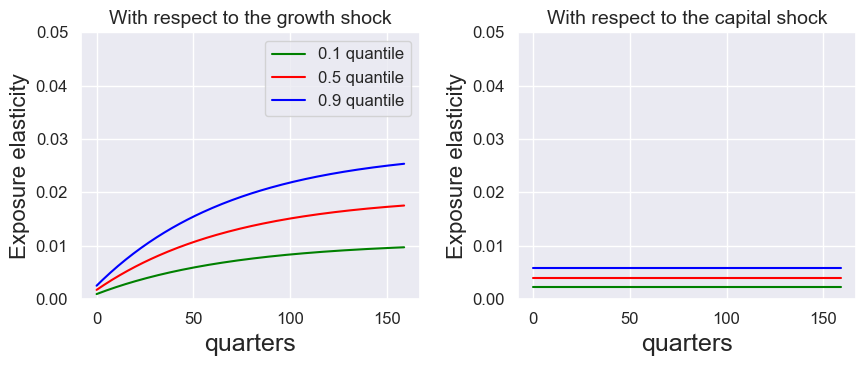

In [17]:
plot_exposure_elasticity(ModelSol, 40*4, [0.1, 0.5, 0.9])

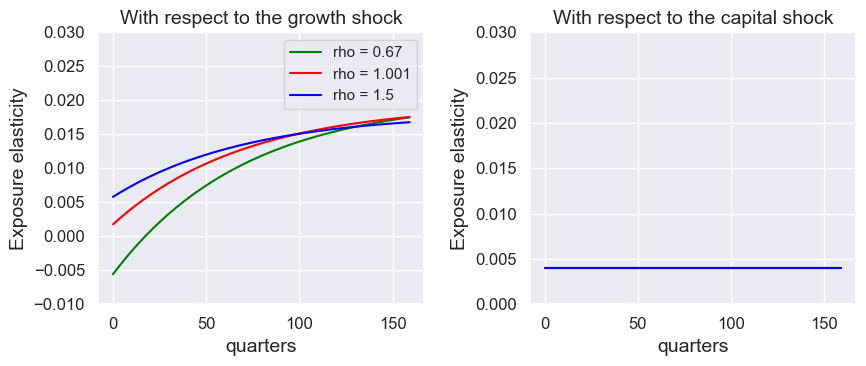

In [ ]:
"""

def plot_exposure_elasticity_compare_rho(models_dict, T, ylimit=None):
    
    # Plots exposure elasticity of consumption for 3 rho values.
    # Style matches user requirements exactly.
    
    sns.set_style("darkgrid")

    # Define Rhos and associated labels/colors
    # Order: 0.67 (Green), 1.001 (Red), 1.5 (Blue)
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [f'rho = {r}' for r in rhos_ordered]
    
    # We need to collect the 0.5 quantile data for all models
    # for Shock 1 (Growth) and Shock 0 (Capital)
    
    # Data containers
    data_shock_1 = [] # Growth shock
    data_shock_0 = [] # Capital shock
    
    time_axis = np.arange(T)
    
    for r in rhos_ordered:
        if r in models_dict:
            mod = models_dict[r]
            # Calculate 0.5 quantile elasticity
            # Shock 1 (Growth)
            elas_1 = exposure_elasticity(mod.gc_tp1, mod.X1_tp1, mod.X2_tp1, T, shock=1, percentile=0.5).flatten()
            data_shock_1.append(elas_1)
            
            # Shock 0 (Capital)
            elas_0 = exposure_elasticity(mod.gc_tp1, mod.X1_tp1, mod.X2_tp1, T, shock=0, percentile=0.5).flatten()
            data_shock_0.append(elas_0)
        else:
            # Handle missing model if solve failed
            data_shock_1.append(np.zeros(T))
            data_shock_0.append(np.zeros(T))

    # Create DataFrames structured for the styling logic
    # The original logic expected columns named by quantile. 
    # Here columns are named by rho.
    
    df_shock_1 = pd.DataFrame(data_shock_1, index=labels, columns=time_axis).T
    df_shock_0 = pd.DataFrame(data_shock_0, index=labels, columns=time_axis).T
    
    # Add 'T' column for plotting
    df_shock_1['T'] = time_axis
    df_shock_0['T'] = time_axis
    
    shock_data = [df_shock_1, df_shock_0]
    
    # Plot settings
    fig, axes = plt.subplots(1, 2, figsize=(9,4))
    shock_name = ['growth shock', 'capital shock']
    
    # Using the colors list defined above
    
    for i in range(len(shock_data)):
        for j, label in enumerate(labels):
            sns.lineplot(data=shock_data[i], x='T', y=label, ax=axes[i], color=colors[j], label=label)
        
        # Customize each subplot (EXACT STYLE FROM PROMPT)
        axes[i].set_xlabel('')  # Optional to clear x-axis label for each subplot
        axes[i].set_ylabel('Exposure elasticity', fontsize=14)
        axes[i].set_title('With respect to the ' + shock_name[i], fontsize=14)
        axes[i].tick_params(axis='y', labelsize=12)
        axes[i].tick_params(axis='x', labelsize=12)
        axes[i].legend(fontsize=11)
    
    # Set y-axis limits for each subplot (EXACT STYLE FROM PROMPT)
    axes[1].set_ylim([-0.01, ylimit])
    axes[0].set_ylim([-0.01, ylimit])
    
    # Note: You had axes[1].set_ylim(bottom=0) in the prompt which overrides the -0.02.
    # I will apply the logic that ensures the axis is positive if that was the intent, 
    # or follow the specific lines provided. 
    # The prompt had both:
    # axes[1].set_ylim([-0.02, ylimit])
    # axes[1].set_ylim(bottom=0)
    # The last command wins in Python.
    axes[1].set_ylim(bottom=0) 
    
    # Set x-axis label for all subplots
    for ax in axes:
        ax.set_xlabel('quarters', fontsize=14)
    
    # Remove legend from right plot
    axes[1].get_legend().remove()

    plt.tight_layout()
    plt.show()

# Run the plotter
plot_exposure_elasticity_compare_rho(stored_models, T=160, ylimit=0.03)

"""

# Exposure Elasticity of Investment-Capital Ratio

The following codes describe how to plot investment-capital ratio from our solved model.

In [36]:
# Log Investment over Output approximation

# Define the target as a SymPy expression
# 'imk_t' is the symbol for I/K defined in your symbols list earlier.
# Since Y = alpha * K, log(I/Y) = log(I/K) - log(alpha). 
# The constant -log(alpha) drops out in elasticity calculations, so we just use log(imk_t).
target_expression = sp.log(imk_t)

#  Use approximate_fun directly (bypassing ModelSol.approximate)
# This handles the symbolic differentiation correctly.
log_IY_t, zero_ord, first_ord, second_ord = approximate_fun(
    fun=target_expression,
    ss=ModelSol.ss,
    ss_variables=ModelSol.ss_variables,
    ss_variables_tp1=ModelSol.ss_variables_tp1,
    parameter_names=ModelSol.parameter_names,
    args=ModelSol.args,
    var_shape=ModelSol.var_shape,
    JX1_t=ModelSol.JX1_t,
    JX2_t=ModelSol.JX2_t,
    X1_tp1=ModelSol.X1_tp1,
    X2_tp1=ModelSol.X2_tp1,
    recursive_ss=ModelSol.recursive_ss,
    second_order=True
)

# 3. Get Linear-Quadratic expansion of log(I/K) at time t+1
log_IY_tp1 = next_period(log_IY_t, ModelSol.X1_tp1, ModelSol.X2_tp1)

# 4. Compute "Growth" (Difference)
# For a stationary ratio, this allows calculating the elasticity of the level.
log_IY_growth = log_IY_tp1 - log_IY_t

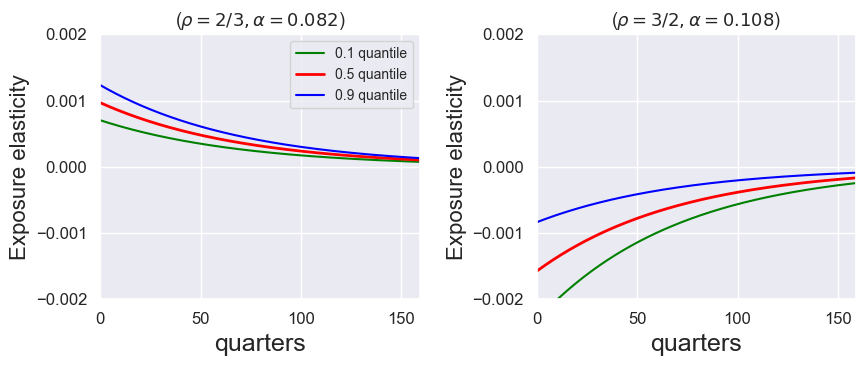

In [34]:
from matplotlib.ticker import MultipleLocator  # <--- Imported for tick control

# =============================================================================
# FUNCTION: PLOT I/Y ELASTICITY (SPECIFIC COLOR/SHAPE MODIFICATION)
# =============================================================================

def plot_IY_elasticity_specific_compare(models_dict, T, ylimits=None):
    """
    Plots Investment-Output elasticity for Growth Shock only.
    Legend appears ONLY on the left graph (Index 0).
    """
    sns.set_style("darkgrid")

    case_left = (0.67, r'$\rho=2/3, \alpha=0.082$')
    case_right = (1.5, r'$\rho=3/2, \alpha=0.108$')
    
    cases = [case_left, case_right]
    quantiles = [0.1, 0.5, 0.9]
    quantile_colors = {0.1: 'green', 0.5: 'red', 0.9: 'blue'}
    
    fig, axes = plt.subplots(1, 2, figsize=(9,4))
    
    time_axis = np.arange(T)
    imk_t_sym = sp.Symbol('imk_t')
    target_expression = sp.log(imk_t_sym)

    # Enumerate gives us the index 'i' (0 for left, 1 for right)
    for i, (rho_val, label_title) in enumerate(cases):
        ax = axes[i]
        
        if rho_val in models_dict:
            mod = models_dict[rho_val]
            
            # --- Approximate log(I/Y) ---
            log_IY_t, _, _, _ = approximate_fun(
                fun=target_expression,
                ss=mod.ss,
                ss_variables=mod.ss_variables,
                ss_variables_tp1=mod.ss_variables_tp1,
                parameter_names=mod.parameter_names,
                args=mod.args,
                var_shape=mod.var_shape,
                JX1_t=mod.JX1_t,
                JX2_t=mod.JX2_t,
                X1_tp1=mod.X1_tp1,
                X2_tp1=mod.X2_tp1,
                recursive_ss=mod.recursive_ss,
                second_order=True
            )
            
            log_IY_tp1 = next_period(log_IY_t, mod.X1_tp1, mod.X2_tp1)
            log_IY_growth = log_IY_tp1 - log_IY_t
            
            # --- Plotting ---
            for q in quantiles:
                elas = exposure_elasticity(log_IY_growth, mod.X1_tp1, mod.X2_tp1, T, shock=1, percentile=q).flatten()
                
                # Plot
                sns.lineplot(
                    x=time_axis, 
                    y=elas, 
                    ax=ax, 
                    color=quantile_colors[q], 
                    label=f'{q} quantile', 
                    linestyle='-', 
                    linewidth=2.0 if q == 0.5 else 1.5
                )
            
        else:
            print(f"Warning: Model for rho={rho_val} not found.")
        
        # --- Styling ---
        ax.set_xlabel('quarters', fontsize=18)
        ax.set_ylabel('Exposure elasticity', fontsize=16)
        ax.set_title(f'({label_title})', fontsize=13)
        
        ax.tick_params(axis='y', labelsize=12)
        ax.tick_params(axis='x', labelsize=12)
        
        # --- CONDITIONAL LEGEND LOGIC ---
        if i == 0:
            # Show legend only on the first plot
            ax.legend(fontsize=10) 
        else:
            # Hide legend on the second plot
            if ax.get_legend():
                ax.get_legend().remove()
        
        # Limits and Ticks
        if ylimits:
            ax.set_ylim(ylimits)
        ax.yaxis.set_major_locator(MultipleLocator(0.001))
        ax.margins(x=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

plot_IY_elasticity_specific_compare(stored_models, T=160, ylimits=[-0.002, 0.002])



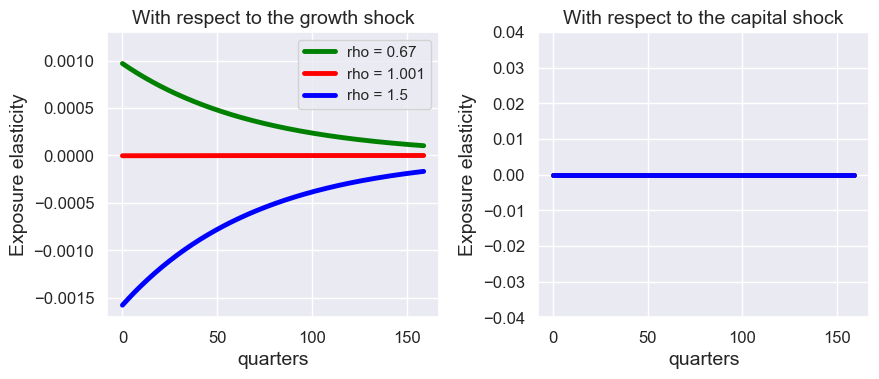

In [435]:
""" def plot_IY_elasticity_compare_rho(models_dict, T, ylimit=0.05):
    
    # Plots exposure elasticity of Investment-Output ratio for 3 rho values.
    # Style matches the Consumption comparison graph exactly.
    
    sns.set_style("darkgrid")

    # Define Rhos and associated labels/colors
    # Order: 0.67 (Green), 1.001 (Red), 1.5 (Blue)
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [f'rho = {r}' for r in rhos_ordered]
    
    # Data containers
    data_shock_1 = [] # Growth shock
    data_shock_0 = [] # Capital shock
    
    time_axis = np.arange(T)
    
    # Loop through models to calculate I/Y elasticity for each
    for r in rhos_ordered:
        if r in models_dict:
            mod = models_dict[r]
            
            # --- 1. Approximate log(I/Y) for this specific model ---
            # Define symbol locally
            imk_t_sym = sp.Symbol('imk_t')
            target_expression = sp.log(imk_t_sym)
            
            # Use approximate_fun
            log_IY_t, _, _, _ = approximate_fun(
                fun=target_expression,
                ss=mod.ss,
                ss_variables=mod.ss_variables,
                ss_variables_tp1=mod.ss_variables_tp1,
                parameter_names=mod.parameter_names,
                args=mod.args,
                var_shape=mod.var_shape,
                JX1_t=mod.JX1_t,
                JX2_t=mod.JX2_t,
                X1_tp1=mod.X1_tp1,
                X2_tp1=mod.X2_tp1,
                recursive_ss=mod.recursive_ss,
                second_order=True
            )
            
            # Get t+1 and Growth
            log_IY_tp1 = next_period(log_IY_t, mod.X1_tp1, mod.X2_tp1)
            log_IY_growth = log_IY_tp1 - log_IY_t
            
            # --- 2. Calculate Elasticities (0.5 Quantile) ---
            # Shock 1 (Growth)
            elas_1 = exposure_elasticity(log_IY_growth, mod.X1_tp1, mod.X2_tp1, T, shock=1, percentile=0.5).flatten()
            data_shock_1.append(elas_1)
            
            # Shock 0 (Capital)
            elas_0 = exposure_elasticity(log_IY_growth, mod.X1_tp1, mod.X2_tp1, T, shock=0, percentile=0.5).flatten()
            data_shock_0.append(elas_0)
            
        else:
            # Handle missing model if solve failed
            print(f"Warning: Model for rho={r} not found.")
            data_shock_1.append(np.zeros(T))
            data_shock_0.append(np.zeros(T))

    # Create DataFrames
    df_shock_1 = pd.DataFrame(data_shock_1, index=labels, columns=time_axis).T
    df_shock_0 = pd.DataFrame(data_shock_0, index=labels, columns=time_axis).T
    
    # Add 'T' column for plotting
    df_shock_1['T'] = time_axis
    df_shock_0['T'] = time_axis
    
    shock_data = [df_shock_1, df_shock_0]
    
    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(9,4))
    shock_name = ['growth shock', 'capital shock']
    
    for i in range(len(shock_data)):
        for j, label in enumerate(labels):
            sns.lineplot(data=shock_data[i], x='T', y=label, ax=axes[i], color=colors[j], label=label)
        
        # Customize each subplot (Exact Style)
        axes[i].set_xlabel('') 
        axes[i].set_ylabel('Exposure elasticity', fontsize=14)
        axes[i].set_title('With respect to the ' + shock_name[i], fontsize=14)
        axes[i].tick_params(axis='y', labelsize=12)
        axes[i].tick_params(axis='x', labelsize=12)
        axes[i].legend(fontsize=11)
    
    # Set y-axis limits (Specific to Investment Ratio per your instructions)
    # Left graph (Growth Shock): 0.0013 limit
    axes[0].set_ylim(top=0.0013)
    
    # Right graph (Capital Shock): +/- ylimit
    axes[1].set_ylim(top=ylimit, bottom=-ylimit)
    
    # Set x-axis label for all subplots
    for ax in axes:
        ax.set_xlabel('quarters', fontsize=14)
    
    # Remove legend from right plot
    axes[1].get_legend().remove()

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

# Assuming 'stored_models' contains the solved models from your previous loop
plot_IY_elasticity_compare_rho(stored_models, T=160, ylimit=0.04)

"""

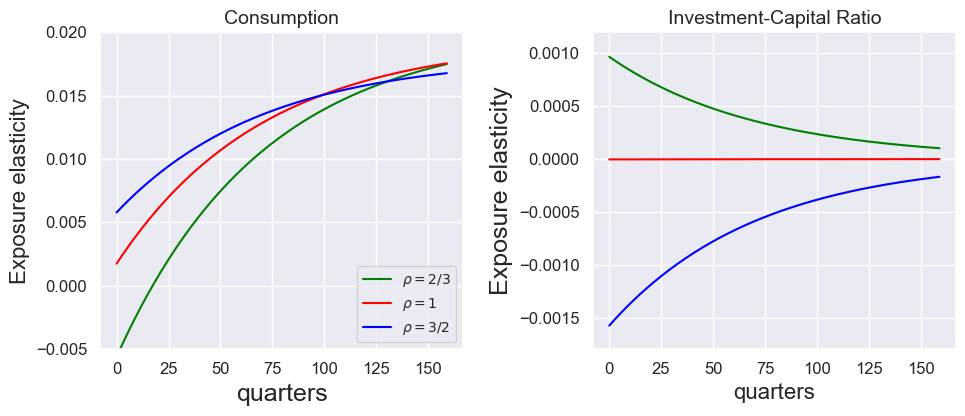

In [37]:
def plot_growth_shock_comparison(models_dict, T, ylim_c=None, ylim_i=None):
    """
    Plots Exposure Elasticity for GROWTH SHOCK only.
    Left Panel: Consumption (for rho = 0.67, 1.001, 1.5)
    Right Panel: Investment-Output Ratio (for rho = 0.67, 1.001, 1.5)
    """
    sns.set_style("darkgrid")

    # Configuration
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']
    
    # Prepare Figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    time_axis = np.arange(T)
    
    # Pre-define symbol for Investment calculation
    imk_t_sym = sp.Symbol('imk_t')
    target_expression = sp.log(imk_t_sym)

    # Loop through rhos
    for idx, r in enumerate(rhos_ordered):
        if r in models_dict:
            mod = models_dict[r]
            color = colors[idx]
            label = labels[idx]
            
            # -------------------------------------------------------
            # 1. Consumption Elasticity (Shock 1 = Growth)
            # -------------------------------------------------------
            elas_c = exposure_elasticity(
                mod.gc_tp1, mod.X1_tp1, mod.X2_tp1, T, shock=1, percentile=0.5
            ).flatten()
            
            sns.lineplot(
                x=time_axis, y=elas_c, ax=axes[0], color=color, label=label
            )

            # -------------------------------------------------------
            # 2. Investment-Output Elasticity (Shock 1 = Growth)
            # -------------------------------------------------------
            # A. Approximate log(I/Y)
            log_IY_t, _, _, _ = approximate_fun(
                fun=target_expression,
                ss=mod.ss,
                ss_variables=mod.ss_variables,
                ss_variables_tp1=mod.ss_variables_tp1,
                parameter_names=mod.parameter_names,
                args=mod.args,
                var_shape=mod.var_shape,
                JX1_t=mod.JX1_t,
                JX2_t=mod.JX2_t,
                X1_tp1=mod.X1_tp1,
                X2_tp1=mod.X2_tp1,
                recursive_ss=mod.recursive_ss,
                second_order=True
            )
            
            # B. Get Growth process
            log_IY_tp1 = next_period(log_IY_t, mod.X1_tp1, mod.X2_tp1)
            log_IY_growth = log_IY_tp1 - log_IY_t
            
            # C. Calculate Elasticity
            elas_i = exposure_elasticity(
                log_IY_growth, mod.X1_tp1, mod.X2_tp1, T, shock=1, percentile=0.5
            ).flatten()
            
            sns.lineplot(
                x=time_axis, y=elas_i, ax=axes[1], color=color, label=label
            )
            
        else:
            print(f"Warning: Model for rho={r} not found.")

    # -------------------------------------------------------
    # Styling & Formatting
    # -------------------------------------------------------
    
    # Panel 0: Consumption
    axes[0].set_title("Consumption", fontsize=14)
    axes[0].set_ylabel('Exposure elasticity', fontsize=16)
    axes[0].set_xlabel('quarters', fontsize=18)
    axes[0].tick_params(axis='both', labelsize=12)
    axes[0].legend(fontsize=10, loc='lower right')
    
    # Limits for Consumption
    if ylim_c:
        axes[0].set_ylim(ylim_c)
    else:
        axes[0].set_ylim(bottom=0)

    # Panel 1: Investment-Capital Ratio
    axes[1].set_title("Investment-Capital Ratio", fontsize=14)
    axes[1].set_ylabel('Exposure elasticity', fontsize=18)
    axes[1].set_xlabel('quarters', fontsize=16)
    axes[1].tick_params(axis='both', labelsize=12)
    
    # Remove duplicate legend on right panel
    if axes[1].get_legend():
        axes[1].get_legend().remove()
        
    # Limits for Investment
    if ylim_i:
        axes[1].set_ylim(ylim_i)
    else:
        axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

# Example limits: 
# Consumption typically [0, 0.03]
# Investment (Growth Shock) is usually very small but positive [0, 0.0013]
plot_growth_shock_comparison(
    stored_models, 
    T=160, 
    ylim_c=[-0.005, 0.02], 
    ylim_i=[-0.0018, 0.0012]
)

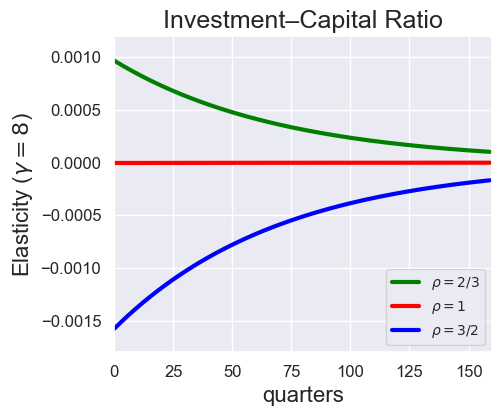

In [39]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import seaborn as sns

def plot_growth_shock_investment_only(models_dict, T, ylim_i=None, save_path=None):
    """
    Plots Exposure Elasticity for GROWTH SHOCK only.
    Single figure: Investment-Capital Ratio (for rho = 0.67, 1.001, 1.5)
    """
    sns.set_style("darkgrid")

    # Configuration
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']

    # Prepare Figure
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
    time_axis = np.arange(T)

    # Symbol for Investment calculation
    imk_t_sym = sp.Symbol('imk_t')
    target_expression = sp.log(imk_t_sym)

    # Loop through rhos
    for idx, r in enumerate(rhos_ordered):
        if r not in models_dict:
            print(f"Warning: Model for rho={r} not found.")
            continue

        mod = models_dict[r]
        color = colors[idx]
        label = labels[idx]

        # A. Approximate log(I/K)
        log_IK_t, _, _, _ = approximate_fun(
            fun=target_expression,
            ss=mod.ss,
            ss_variables=mod.ss_variables,
            ss_variables_tp1=mod.ss_variables_tp1,
            parameter_names=mod.parameter_names,
            args=mod.args,
            var_shape=mod.var_shape,
            JX1_t=mod.JX1_t,
            JX2_t=mod.JX2_t,
            X1_tp1=mod.X1_tp1,
            X2_tp1=mod.X2_tp1,
            recursive_ss=mod.recursive_ss,
            second_order=True
        )

        # B. Growth process
        log_IK_tp1 = next_period(log_IK_t, mod.X1_tp1, mod.X2_tp1)
        log_IK_growth = log_IK_tp1 - log_IK_t

        # C. Exposure elasticity (Growth shock)
        elas_i = exposure_elasticity(
            log_IK_growth, mod.X1_tp1, mod.X2_tp1, T, shock=1, percentile=0.5
        ).flatten()

        sns.lineplot(
            x=time_axis, y=elas_i, ax=ax, color=color, label=label ,linewidth=3. 
        )

    # Styling
    ax.set_title("Investment–Capital Ratio", fontsize=18)
    ax.set_ylabel(r"Elasticity ($\gamma=8$)", fontsize=16)
    ax.set_xlabel("quarters", fontsize=16)
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=10, loc="lower right")
    ax.set_xlim(0, T)
    
    if ylim_i is not None:
        ax.set_ylim(ylim_i)
    else:
        ax.set_ylim(bottom=0)
    

    plt.tight_layout()

    # Save figure
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# =============================================================================
# EXECUTE
# =============================================================================

# Create stored_models dictionary from the available model (sol)
# If you have models for different rho values, create a dict like: {0.67: model1, 1.001: model2, 1.5: model3}
# stored_models = {1.001: sol}  # Replace with your actual models dict for different rho values

plot_growth_shock_investment_only(
    stored_models,
    T=160,
    ylim_i=[-0.0018, 0.0012],
    # save_path="../../../../images/expo_elasticity_investment_varrho.jpg"
)


It is also possible to compute price elasticities similarly:

In [40]:
def plot_price_elasticity(res, T, quantile, save_path=None,ylimit=0.5, linewidth=None):
    """
    Calculate and plot price elasticity for different shocks.
    
    Parameters:
    - res: DataFrame containing input data with necessary columns.
    - T: Integer, time horizon.
    - quantile: List of quantiles to calculate.
    - save_path: Optional, path to save the figure.
    """
    sns.set_style("darkgrid")

    # Extract variables from res
    X1_tp1 = res['X1_tp1']
    X2_tp1 = res['X2_tp1']
    gc_tp1 = res['gc_tp1']
    if 'parameter_names' in res:
        γ = get_parameter_value('gamma', res['parameter_names'], res['args'])
        β = get_parameter_value('beta', res['parameter_names'], res['args'])
        ρ = get_parameter_value('rho', res['parameter_names'], res['args'])
    else:
        β = res['args'][1]
        ρ = res['args'][2]
    vmr_tp1 = res['vmr1_tp1'] + 0.5 * res['vmr2_tp1']
    logNtilde = res['log_N_tilde']
    
    # Calculate log_SDF
    log_SDF = np.log(β) - ρ * gc_tp1 + (ρ - 1) * vmr_tp1 + logNtilde
    # log_SDF = np.log(β) - ρ * gc_tp1 
    
    # Calculate price elasticity for different shocks
    price_elas_shock_0 = [price_elasticity(gc_tp1, log_SDF, X1_tp1, X2_tp1, T, shock=0, percentile=p) for p in quantile]
    price_elas_shock_1 = [price_elasticity(gc_tp1, log_SDF, X1_tp1, X2_tp1, T, shock=1, percentile=p) for p in quantile]
    price_elas_shock_2 = [price_elasticity(gc_tp1, log_SDF, X1_tp1, X2_tp1, T, shock=2, percentile=p) for p in quantile]

    # Prepare data for plotting
    index = ['T', '0.1 quantile', '0.5 quantile', '0.9 quantile']
    shock_data = [
        pd.DataFrame([np.arange(T), *[e.flatten() for e in price_elas_shock_1]], index=index).T,
        pd.DataFrame([np.arange(T), *[e.flatten() for e in price_elas_shock_0]], index=index).T,
        pd.DataFrame([np.arange(T), *[-e.flatten() for e in price_elas_shock_2]], index=index).T
    ]
    
    # Plot settings
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    shock_name = ['growth shock', 'capital shock', 'volatility shock']
    qt = ['0.1 quantile', '0.5 quantile', '0.9 quantile']
    colors = ['green', 'red', 'blue']
    
    for i in range(len(shock_data))[:2]:
        for j in range(len(quantile)):
            sns.lineplot(data=shock_data[i], x='T', y=qt[j], ax=axes[i], color=colors[j], label=qt[j], linewidth=linewidth)
        
        # Customize each subplot
        axes[i].set_xlabel('')  # Optional to clear x-axis label for each subplot
        axes[i].set_ylabel('Price elasticity', fontsize=16)
        axes[i].set_title('With respect to the ' + shock_name[i], fontsize=14)
        axes[i].tick_params(axis='y', labelsize=12)
        axes[i].tick_params(axis='x', labelsize=12)
        axes[i].legend(fontsize=12)
    
    # Set y-axis limits for each subplot
    axes[0].set_ylim([0.0, 0.5])
    axes[1].set_ylim([0, ylimit])
    axes[0].set_xlim([0, T])
    axes[1].set_xlim([0, T])
    # axes[2].set_ylim([0, 0.5])

    # Set x-axis label for all subplots
    for ax in axes:
        ax.set_xlabel('quarters', fontsize=12)

    fig.tight_layout()
    # Save and show plot
    if save_path:
        plt.savefig(save_path, dpi=500)
    plt.show()
def get_parameter_value(parameter_name, parameter_names, args):
    """
    Retrieve the value of a parameter from the args list based on its name.

    Parameters
    ----------
    parameter_name : str
        The name of the parameter to retrieve (e.g., 'beta_2').
    parameter_names : dict
        A dictionary mapping parameter names (keys) to symbolic variables (values).
    args : list
        A list of parameter values corresponding to the order of parameter_names.

    Returns
    -------
    value : float
        The value of the requested parameter.

    Raises
    ------
    ValueError
        If the parameter name is not found in parameter_names.
    """
    # Convert parameter_names keys to a list to get the index
    try:
        parameter_index = list(parameter_names.keys()).index(parameter_name)
    except ValueError:
        raise ValueError(f"Parameter '{parameter_name}' not found in parameter_names.")
    
    # Retrieve the value from args
    return args[parameter_index]

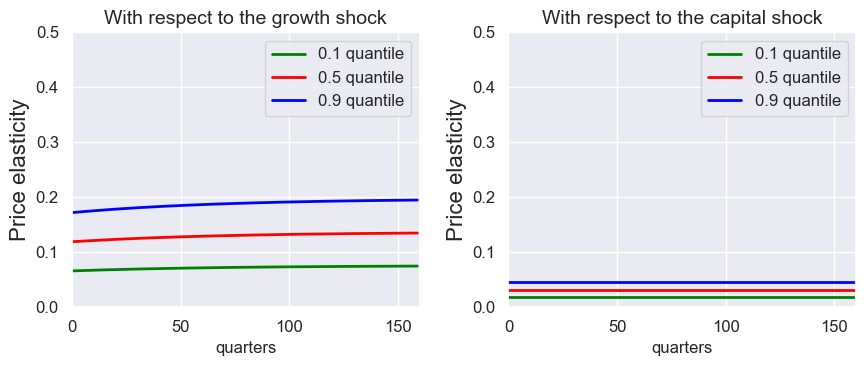

In [41]:
plot_price_elasticity(ModelSol,40*4,[0.1,0.5,0.9], linewidth=2)

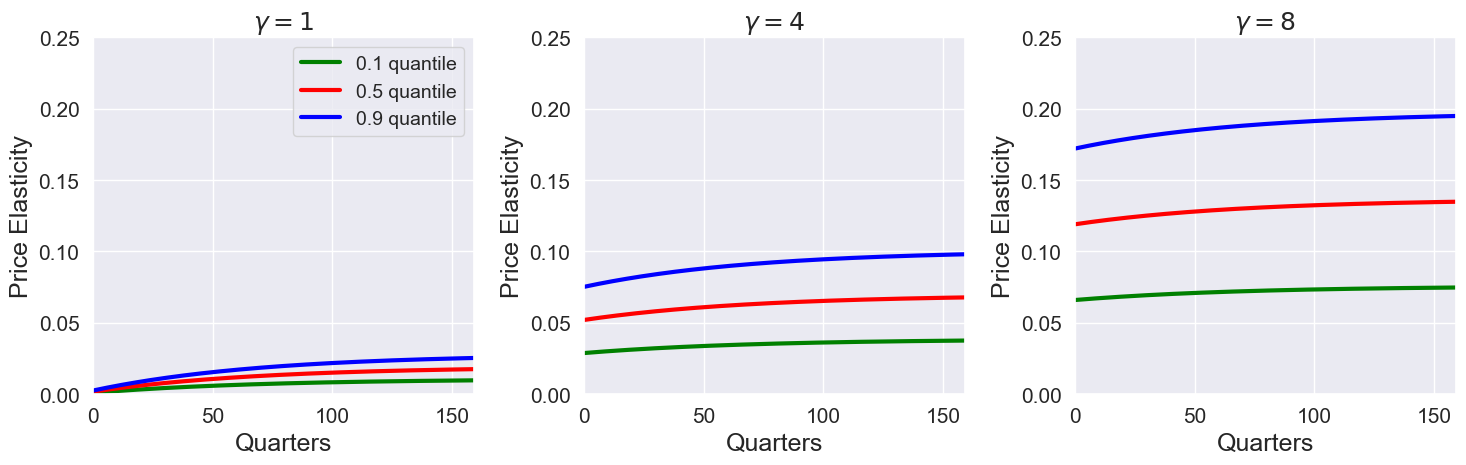

In [108]:
def plot_IK_price_elasticity_gamma_compare(models_dict, T=160, ylimit=None, linewidth=None):
    """
    Plots Price Elasticity of Investment-Capital Ratio for 3 Gamma values.
    Fixed Rho = 1.001.
    Shock: Growth Shock (Index 1).
    """
    sns.set_style("darkgrid")
    
    # Configuration
    gammas_ordered = [1.001, 4.001, 8.001]
    quantiles = [0.1, 0.5, 0.9]
    colors = ['green', 'red', 'blue'] # Colors for Quantiles
    
    # Create 3 subplots side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    time_axis = np.arange(T)
    
    # Symbol for I/K approximation
    imk_t_sym = sp.Symbol('imk_t')
    target_expression = sp.log(imk_t_sym)

    for idx, g_val in enumerate(gammas_ordered):
        ax = axes[idx]
        
        if g_val in models_dict:
            mod = models_dict[g_val]
            
            # --- 1. Reconstruct SDF ---
            # We need rho and beta from the model parameters
            # Assuming standard order or retrieving from dict
            try:
                p_names = list(mod.parameter_names.keys()) if isinstance(mod.parameter_names, dict) else mod.parameter_names
                rho_idx = p_names.index('rho')
                beta_idx = p_names.index('beta')
                rho_val = mod.args[rho_idx]
                beta_val = mod.args[beta_idx]
            except:
                # Fallback if lookup fails
                rho_val = 1.001
                # Recalculate beta based on epsilon=0.25, delta=0.01
                beta_val = np.exp(-0.01 * 0.25)

            # Construct log SDF
            vmr_tp1 = mod.vmr1_tp1 + 0.5 * mod.vmr2_tp1
            logNtilde = mod.log_N_tilde
            log_SDF = np.log(beta_val) - rho_val * mod.gc_tp1 + (rho_val - 1) * vmr_tp1 + logNtilde

            # --- 2. Approximate log(I/K) ---
            log_IY_t, _, _, _ = approximate_fun(
                fun=target_expression,
                ss=mod.ss,
                ss_variables=mod.ss_variables,
                ss_variables_tp1=mod.ss_variables_tp1,
                parameter_names=mod.parameter_names,
                args=mod.args,
                var_shape=mod.var_shape,
                JX1_t=mod.JX1_t,
                JX2_t=mod.JX2_t,
                X1_tp1=mod.X1_tp1,
                X2_tp1=mod.X2_tp1,
                recursive_ss=mod.recursive_ss,
                second_order=True
            )
            
            # Growth of I/K
            log_IY_tp1 = next_period(log_IY_t, mod.X1_tp1, mod.X2_tp1)
            log_IY_growth = log_IY_tp1 - log_IY_t
            
            # --- 3. Calculate Price Elasticity ---
            # Shock 1 = Growth Shock
            target_shock = 1 
            
            for j, q in enumerate(quantiles):
                elas = price_elasticity(
                    log_IY_growth, 
                    log_SDF, 
                    mod.X1_tp1, 
                    mod.X2_tp1, 
                    T, 
                    shock=target_shock, 
                    percentile=q
                ).flatten()
                
                # Plot
                sns.lineplot(
                    x=time_axis, 
                    y=elas, 
                    ax=ax, 
                    color=colors[j], 
                    linewidth=linewidth,
                    label=f'{q} quantile'
                )
        else:
            print(f"Model for Gamma={g_val} not found.")

        # --- Styling ---
        ax.set_title(f"$\gamma = {int(g_val)}$", fontsize=18)
        ax.set_xlabel("Quarters", fontsize=18)
        
        if idx == 0:
            ax.set_ylabel("Price Elasticity", fontsize=18)
            ax.legend(fontsize=14, loc='upper right')
        else:
            ax.set_ylabel("Price Elasticity", fontsize=18)
            if ax.get_legend(): ax.get_legend().remove()
            
        ax.tick_params(labelsize=15)
        
        if ylimit:
            ax.set_ylim(ylimit)
        else:
            ax.set_ylim(bottom=0)
            
        ax.margins(x=0)

    plt.tight_layout()
    plt.show()

# EXECUTE PLOTTING
plot_IK_price_elasticity_gamma_compare(stored_models_gamma, T=160, ylimit=[0, 0.25], linewidth = 3)

In [43]:
# =============================================================================
# 2. SOLVER LOOP (All Combinations)
# =============================================================================
gammas = [1.001, 4.001, 8.001]
rhos = [0.67, 1.001, 1.5]
stored_models_full = {}

print("--- Starting Solver Loop ---")

for g_val in gammas:
    for r_val in rhos:
        key = (g_val, r_val)
        print(f"Solving: Gamma={g_val}, Rho={r_val}...")
        
        # Generate Args
        param_lambda = lambda: create_args_gamma_sweep(gamma=g_val, rho=r_val)
        parameter_names, args = generate_symbols_and_args(param_lambda)
        
        # Symbols
        sym_dict = {name: sp.Symbol(name) for name in parameter_names}
        sym_dict.update({var: sp.Symbol(var) for var in variables + variables_tp1})
        
        imk_t = sym_dict["imk_t"]
        Z_t = sym_dict["Z_t"]; Y_t = sym_dict["Y_t"]; q_t = sym_dict["q_t"]
        W1_tp1 = sym_dict["W1_tp1"]; W2_tp1 = sym_dict["W2_tp1"]; W3_tp1 = sym_dict["W3_tp1"]
        
        a_sym = sym_dict["a"]; epsilon = sym_dict["epsilon"]
        phi_1 = sym_dict["phi_1"]; phi_2 = sym_dict["phi_2"]
        alpha_k = sym_dict["alpha_k"]; beta_k = sym_dict["beta_k"]
        sigma_k1 = sym_dict["sigma_k1"]; sigma_k2 = sym_dict["sigma_k2"]; sigma_k3 = sym_dict["sigma_k3"]
        sigma_z1 = sym_dict["sigma_z1"]; sigma_z2 = sym_dict["sigma_z2"]; sigma_z3 = sym_dict["sigma_z3"]
        sigma_y1 = sym_dict["sigma_y1"]; sigma_y2 = sym_dict["sigma_y2"]; sigma_y3 = sym_dict["sigma_y3"]
        beta_z = sym_dict["beta_z"]; beta_2 = sym_dict["beta_2"]; mu_2 = sym_dict["mu_2"]

        # Equations
        kappa = sp.log(a_sym - imk_t)
        growth = epsilon * (phi_1 * sp.log(1. + phi_2 * imk_t) - alpha_k + beta_k * Z_t \
                            - q_t**2 * 0.5 * (sigma_k1**2 + sigma_k2**2 + sigma_k3**2) * sp.exp(Y_t)) \
                            + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_k1 * W1_tp1 + sigma_k2 * W2_tp1 + sigma_k3 * W3_tp1)       
        
        technology_growth = Z_t - epsilon * beta_z * Z_t \
                                        + sp.sqrt(epsilon) * sp.exp(0.5 * Y_t) * (sigma_z1 * W1_tp1 + sigma_z2 * W2_tp1 + sigma_z3 * W3_tp1)
        
        volatility_growth = Y_t - epsilon * beta_2 * (1 - mu_2 * sp.exp(-Y_t)) \
                                - q_t**2 * 0.5 * (sigma_y1**2 + sigma_y2**2 + sigma_y3**2) * sp.exp(-Y_t) * epsilon \
                                + sp.exp(-0.5 * Y_t) * (sigma_y1 * W1_tp1 + sigma_y2 * W2_tp1 + sigma_y3 * W3_tp1) * sp.sqrt(epsilon)
        
        state_equations = [technology_growth, volatility_growth]

        # Solve
        try:
            sol = uncertain_expansion(
                control_variables, state_variables, shock_variables, variables, variables_tp1,
                kappa, growth, state_equations, static_constraints, initial_guess, parameter_names,
                args, approach='1', iter_tol=1e-4, max_iter=500
            )
            stored_models_full[key] = sol
        except Exception as e:
            print(f"Error: {e}")

--- Starting Solver Loop ---
Solving: Gamma=1.001, Rho=0.67...
Iteration 1: mu_0 error = 6.31886579e-18
Iteration 1: J1 error = 0.309021797
Iteration 1: J2 error = 0.312487303
Iteration 1: error = 0.312487303
Iteration 2: mu_0 error = 9.82558219e-20
Iteration 2: J1 error = 0.00845606955
Iteration 2: J2 error = 0.00556995758
Iteration 2: error = 0.00845606955
Iteration 3: mu_0 error = 1.28749008e-19
Iteration 3: J1 error = 0.000225258581
Iteration 3: J2 error = 0.000549093978
Iteration 3: error = 0.000549093978
Iteration 4: mu_0 error = 5.08219768e-20
Iteration 4: J1 error = 4.02591247e-06
Iteration 4: J2 error = 0.000223994786
Iteration 4: error = 0.000223994786
Iteration 5: mu_0 error = 5.75982404e-20
Iteration 5: J1 error = 5.81134401e-07
Iteration 5: J2 error = 7.30003259e-05
Iteration 5: error = 7.30003259e-05
Solving: Gamma=1.001, Rho=1.001...
Iteration 1: mu_0 error = 4.40457133e-20
Iteration 1: J1 error = 0.000561673557
Iteration 1: J2 error = 0.000554625148
Iteration 1: error =

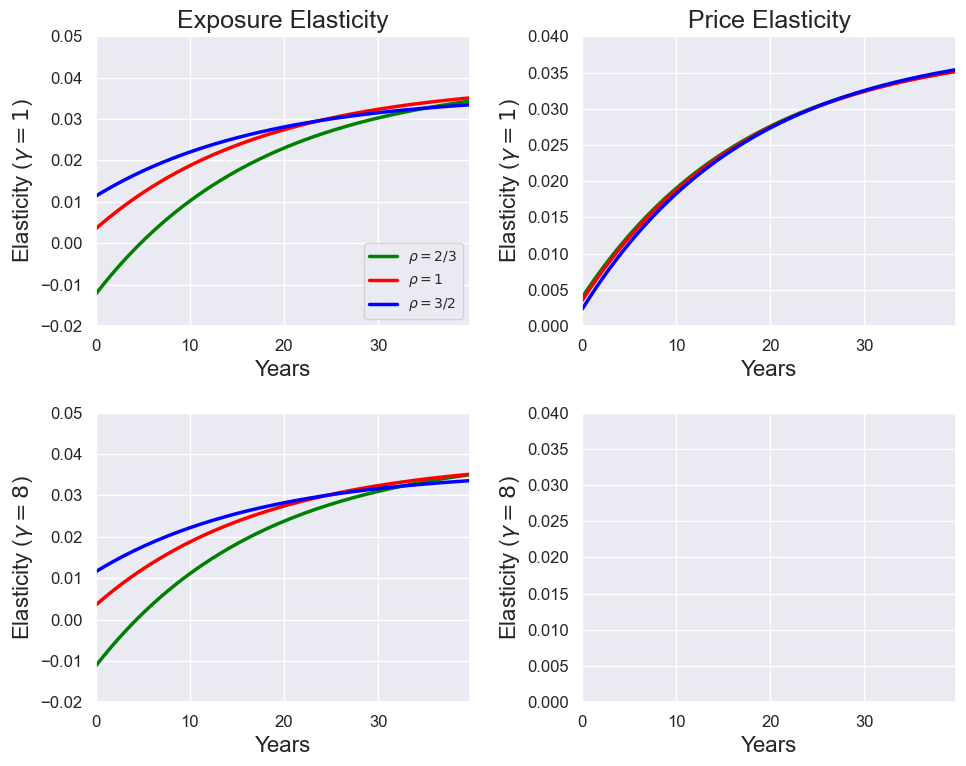

In [37]:
# Annualized Version

def plot_2x2_elasticity_grid(models_dict, T=160, ylim_expo=None, ylim_price=None):
    """
    2x2 Grid Plot.
    Annualizes the Quarterly solver output (Scaling Y by 1/sqrt(epsilon)).
    Rows: Gamma = 1, Gamma = 8
    Cols: Exposure Elasticity, Price Elasticity
    """
    sns.set_style("darkgrid")
    
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']
    gammas_rows = [1.001, 8.001]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    # Target Shock: Growth (Index 1)
    target_shock = 1
    
    for row_idx, g_val in enumerate(gammas_rows):
        for r_idx, r_val in enumerate(rhos_ordered):
            key = (g_val, r_val)
            
            if key in models_dict:
                mod = models_dict[key]
                color = colors[r_idx]
                label = labels[r_idx]
                
                # --- RETRIEVE EPSILON FOR SCALING ---
                # We need epsilon to annualize the time axis and the elasticity magnitude
                try:
                    p_names = list(mod.parameter_names.keys()) if isinstance(mod.parameter_names, dict) else mod.parameter_names
                    eps_idx = p_names.index('epsilon')
                    epsilon = mod.args[eps_idx]
                except:
                    epsilon = 0.25 # Default to quarterly
                
                # 1. SCALE TIME AXIS (Quarters -> Years)
                time_axis = np.arange(T) * epsilon
                
                # 2. SCALE ELASTICITY (Quarterly Magnitude -> Annual Magnitude)
                # Shock in discrete time is scaled by sqrt(epsilon).
                # To compare with annual, we divide by sqrt(epsilon).
                scale_factor = 1.0 / np.sqrt(epsilon)
                
                # --- Exposure Elasticity (Column 0) ---
                elas_expo = exposure_elasticity(
                    mod.gc_tp1, mod.X1_tp1, mod.X2_tp1, T, shock=target_shock, percentile=0.5
                ).flatten() * scale_factor
                
                sns.lineplot(
                    x=time_axis, y=elas_expo, ax=axes[row_idx, 0], color=color, label=label, linewidth=2.5
                )
                
                # --- Price Elasticity (Column 1) ---
                # Reconstruct SDF
                try:
                    beta_val = mod.args[p_names.index('beta')]
                except:
                    beta_val = np.exp(-0.01 * epsilon)
                
                vmr_tp1 = mod.vmr1_tp1 + 0.5 * mod.vmr2_tp1
                logNtilde = mod.log_N_tilde
                log_SDF = np.log(beta_val) - r_val * mod.gc_tp1 + (r_val - 1) * vmr_tp1 + logNtilde
                
                elas_price = price_elasticity(
                    mod.gc_tp1, log_SDF, mod.X1_tp1, mod.X2_tp1, T, shock=target_shock, percentile=0.5
                ).flatten() * scale_factor
                
                sns.lineplot(
                    x=time_axis, y=elas_price, ax=axes[row_idx, 1], color=color, label=label, linewidth=2.5
                )
            else:
                print(f"Missing model: {key}")

    # --- STYLING ---
    for ax in axes.flatten():
        ax.set_xlabel("Years", fontsize=16)
        ax.tick_params(labelsize=12)
        ax.margins(x=0)
        
    axes[0, 0].set_title("Exposure Elasticity", fontsize=18)
    axes[0, 1].set_title("Price Elasticity", fontsize=18)
    
    axes[0, 0].set_ylabel(r"Elasticity ($\gamma=1$)", fontsize=16)
    axes[1, 0].set_ylabel(r"Elasticity ($\gamma=8$)", fontsize=16)
    axes[0, 1].set_ylabel(r"Elasticity ($\gamma=1$)", fontsize=16)
    axes[1, 1].set_ylabel(r"Elasticity ($\gamma=8$)", fontsize=16)

    # Legend only in Top Left
    axes[0, 0].legend(fontsize=10, loc='lower right')
    axes[0, 1].get_legend().remove()
    axes[1, 0].get_legend().remove()
    axes[1, 1].get_legend().remove()
    
    # Limits (Applied to scaled values)
    if ylim_expo:
        axes[0, 0].set_ylim(ylim_expo)
        axes[1, 0].set_ylim(ylim_expo)
    else:
        axes[0, 0].set_ylim(bottom=0)
        axes[1, 0].set_ylim(bottom=0)
        
    if ylim_price:
        axes[0, 1].set_ylim(ylim_price)
        axes[1, 1].set_ylim(ylim_price)
    else:
        axes[0, 1].set_ylim(bottom=0)
        axes[1, 1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

# Note: We still calculate T=160 steps to get 40 years of data (160 * 0.25 = 40)
plot_2x2_elasticity_grid(
    stored_models_full, 
    T=160, 
    ylim_expo=[-0.02, 0.05], 
    ylim_price=[0.00, 0.04]
)

NUMERICAL VERIFICATION (Gamma = 1.001)
Identity Check: P = -S

Model: Rho = 0.67
Time  | G            | S (Raw)      | -S           | P (G-V)     
---------------------------------------------------------------------------
0     | -0.006136     | -0.001974     |  0.001974     |  0.001974
1     | -0.005771     | -0.002218     |  0.002218     |  0.002218
40    |  0.005103     | -0.009504     |  0.009504     |  0.009504
80    |  0.011497     | -0.013789     |  0.013789     |  0.013788
159   |  0.017166     | -0.017587     |  0.017587     |  0.017585

Model: Rho = 1.001
Time  | G            | S (Raw)      | -S           | P (G-V)     
---------------------------------------------------------------------------
0     |  0.001753     | -0.001755     |  0.001755     |  0.001755
1     |  0.002000     | -0.002002     |  0.002002     |  0.002002
40    |  0.009375     | -0.009385     |  0.009385     |  0.009385
80    |  0.013712     | -0.013726     |  0.013726     |  0.013726
159   |  0.017557    

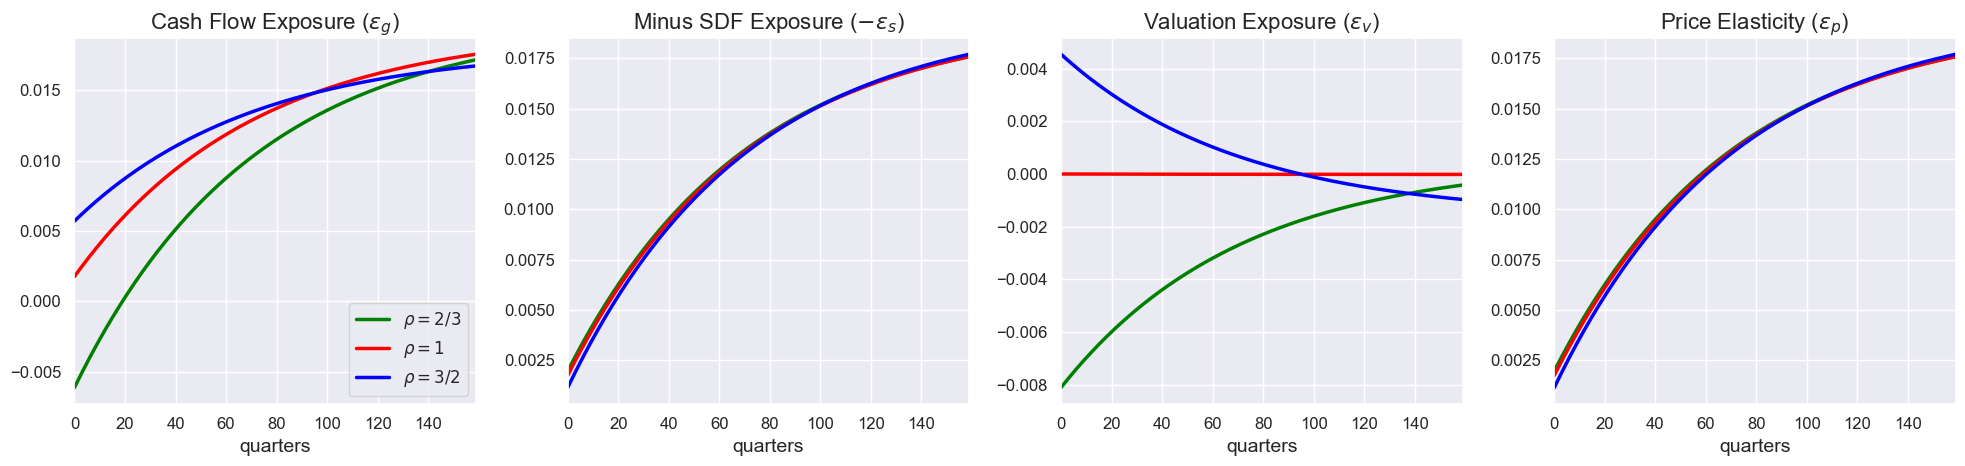

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from elasticity import exposure_elasticity

def get_intertemporal_sdf(model):
    """
    Constructs the log SDF growth for the Intertemporal Preference Model.
    Formula: log S = log(beta) - rho * gc + (rho-1) * vmr + log_N
    """
    try:
        p_names = list(model.parameter_names.keys()) if isinstance(model.parameter_names, dict) else model.parameter_names
        rho_idx = p_names.index('rho')
        beta_idx = p_names.index('beta')
        rho_val = model.args[rho_idx]
        beta_val = model.args[beta_idx]
    except:
        rho_val = 1.001
        beta_val = np.exp(-0.01 * 0.25)

    gc_tp1 = model.gc_tp1
    vmr_tp1 = model.vmr1_tp1 + 0.5 * model.vmr2_tp1
    logNtilde = model.log_N_tilde

    log_S = np.log(beta_val) - rho_val * gc_tp1 + (rho_val - 1) * vmr_tp1 + logNtilde
    
    return log_S

def plot_price_decomposition_intertemporal(models_dict, target_gamma, T=160, ylimit=None):
    """
    Plots decomposition AND prints numerical verification.
    Decomposition:
    1. Cash Flow Exposure (G)
    2. Minus SDF Exposure (-S)  <-- This equals Price Elasticity
    3. Valuation Exposure (V = G+S)
    4. Price Elasticity (P = G-V)
    """
    sns.set_style("darkgrid")
    
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']
    
    # 4 Panels
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    time_axis = np.arange(T)
    shock_idx = 1 # Growth Shock
    
    print(f"{'='*110}")
    print(f"NUMERICAL VERIFICATION (Gamma = {target_gamma})")
    print(f"Identity Check: P = -S")
    print(f"{'='*110}")

    for i, r_val in enumerate(rhos_ordered):
        key = (target_gamma, r_val)
        
        if key in models_dict:
            mod = models_dict[key]
            try:
                # --- 1. Define Processes ---
                log_G = mod.gc_tp1                 # Cash Flow
                log_S = get_intertemporal_sdf(mod) # SDF
                log_V = log_G + log_S              # Valuation
                
                # --- 2. Calculate Elasticities ---
                # A. Cash Flow (G)
                elas_G = exposure_elasticity(
                    log_G, mod.X1_tp1, mod.X2_tp1, T, shock=shock_idx, percentile=0.5
                ).flatten()

                # B. SDF (S) -> We calculate Minus S
                elas_S_raw = exposure_elasticity(
                    log_S, mod.X1_tp1, mod.X2_tp1, T, shock=shock_idx, percentile=0.5
                ).flatten()
                elas_minus_S = -1.0 * elas_S_raw # <--- NEGATED

                # C. Valuation (V)
                elas_V = exposure_elasticity(
                    log_V, mod.X1_tp1, mod.X2_tp1, T, shock=shock_idx, percentile=0.5
                ).flatten()
                
                # D. Price Elasticity (P)
                elas_P = elas_G - elas_V
                
                # --- 3. PRINT VERIFICATION ---
                # We print S_raw to show it's negative, but compare -S to P
                print(f"\nModel: Rho = {r_val}")
                print(f"{'Time':<5} | {'G':<12} | {'S (Raw)':<12} | {'-S':<12} | {'P (G-V)':<12}")
                print("-" * 75)
                
                check_points = [0, 1, 40, 80, T-1]
                for t in check_points:
                    print(f"{t:<5} | {elas_G[t]: .6f}     | {elas_S_raw[t]: .6f}     | {elas_minus_S[t]: .6f}     | {elas_P[t]: .6f}")

                # --- 4. Plot ---
                # Panel 0: Cash Flow
                sns.lineplot(x=time_axis, y=elas_G, ax=axes[0], color=colors[i], label=labels[i], linewidth=2.5)
                
                # Panel 1: MINUS SDF (This represents the Risk Premium contribution)
                sns.lineplot(x=time_axis, y=elas_minus_S, ax=axes[1], color=colors[i], label=labels[i], linewidth=2.5)
                
                # Panel 2: Valuation
                sns.lineplot(x=time_axis, y=elas_V, ax=axes[2], color=colors[i], label=labels[i], linewidth=2.5)
                
                # Panel 3: Price
                sns.lineplot(x=time_axis, y=elas_P, ax=axes[3], color=colors[i], label=labels[i], linewidth=2.5)
                
            except Exception as e:
                print(f"Error processing {key}: {e}")
        else:
            print(f"Model {key} not found.")

    # --- STYLING ---
    titles = [
        r"Cash Flow Exposure ($\varepsilon_g$)", 
        r"Minus SDF Exposure ($-\varepsilon_s$)", 
        r"Valuation Exposure ($\varepsilon_v$)", 
        r"Price Elasticity ($\varepsilon_p$)"
    ]
    
    for idx, ax in enumerate(axes):
        ax.set_title(titles[idx], fontsize=16)
        ax.set_xlabel("quarters", fontsize=14)
        ax.tick_params(labelsize=12)
        
        # Legend only on first plot
        if idx == 0:
            ax.legend(fontsize=12, loc='lower right')
        elif ax.get_legend():
            ax.get_legend().remove()
            
        if ylimit:
             ax.set_ylim(ylimit)
        
        ax.margins(x=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

plot_price_decomposition_intertemporal(
    stored_models_full, 
    target_gamma=1.001, 
    T=160,
    ylimit=None
)

NUMERICAL VERIFICATION (Gamma = 1.001)
Identities: V = G + S  |  P = G - V  |  P = -S

Model: Rho = 0.67
Time  | G (Cash)     | S (SDF)      | -S           | V (Val)      | P (Price)   
------------------------------------------------------------------------------------------
0     | -0.006136     | -0.001974     |  0.001974     | -0.008110     |  0.001974
1     | -0.005771     | -0.002218     |  0.002218     | -0.007989     |  0.002218
5     | -0.004361     | -0.003163     |  0.003163     | -0.007524     |  0.003163
8     | -0.003355     | -0.003837     |  0.003837     | -0.007192     |  0.003837

Model: Rho = 1.001
Time  | G (Cash)     | S (SDF)      | -S           | V (Val)      | P (Price)   
------------------------------------------------------------------------------------------
0     |  0.001753     | -0.001755     |  0.001755     | -0.000002     |  0.001755
1     |  0.002000     | -0.002002     |  0.002002     | -0.000002     |  0.002002
5     |  0.002957     | -0.002960     |

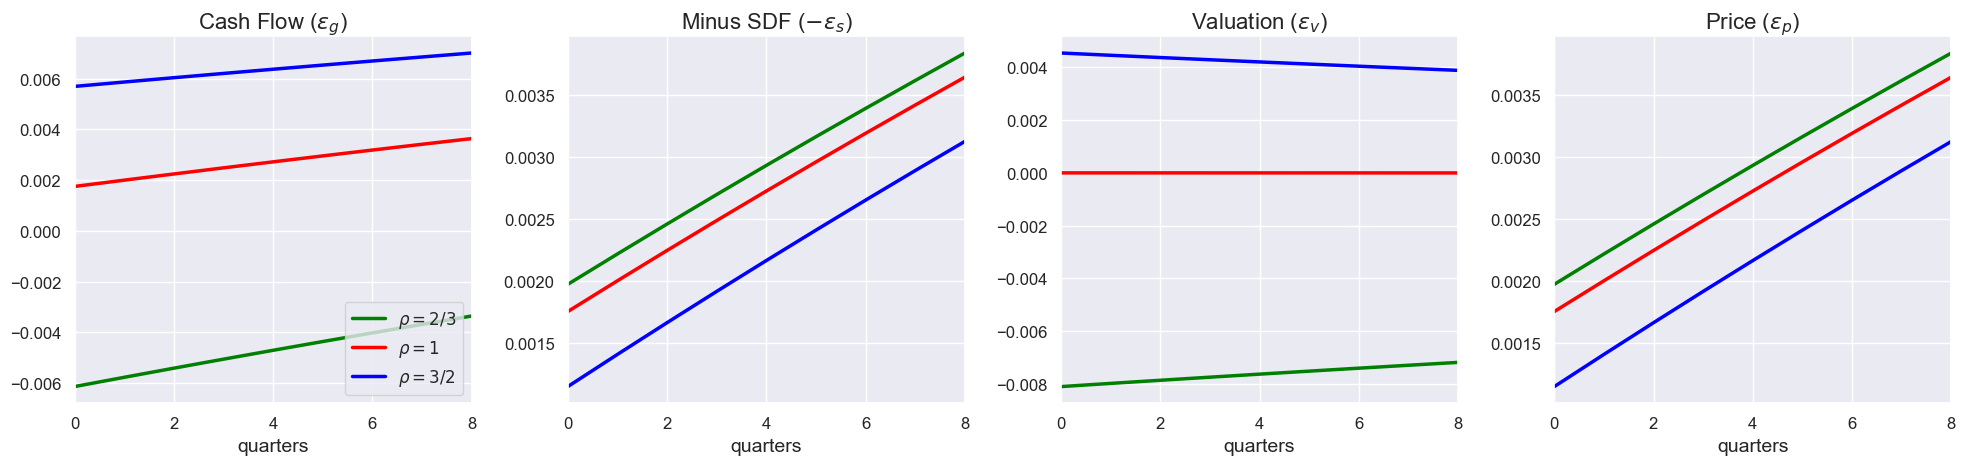

In [77]:
def get_intertemporal_sdf(model):
    """
    Constructs the log SDF growth for the Intertemporal Preference Model.
    Formula: log S = log(beta) - rho * gc + (rho-1) * vmr + log_N
    """
    try:
        p_names = list(model.parameter_names.keys()) if isinstance(model.parameter_names, dict) else model.parameter_names
        rho_idx = p_names.index('rho')
        beta_idx = p_names.index('beta')
        rho_val = model.args[rho_idx]
        beta_val = model.args[beta_idx]
    except:
        rho_val = 1.001
        beta_val = np.exp(-0.01 * 0.25)

    gc_tp1 = model.gc_tp1
    vmr_tp1 = model.vmr1_tp1 + 0.5 * model.vmr2_tp1
    logNtilde = model.log_N_tilde

    log_S = np.log(beta_val) - rho_val * gc_tp1 + (rho_val - 1) * vmr_tp1 + logNtilde
    return log_S

def plot_price_decomposition_intertemporal(models_dict, target_gamma, T=160, ylimit=None):
    """
    Plots decomposition AND prints numerical verification including V.
    Decomposition:
    1. Cash Flow (G)
    2. SDF (S)
    3. Valuation (V = G+S)
    4. Price Elasticity (P = G-V = -S)
    """
    sns.set_style("darkgrid")
    
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']
    
    # 4 Panels
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    time_axis = np.arange(T)
    shock_idx = 1 # Growth Shock
    
    print(f"{'='*115}")
    print(f"NUMERICAL VERIFICATION (Gamma = {target_gamma})")
    print(f"Identities: V = G + S  |  P = G - V  |  P = -S")
    print(f"{'='*115}")

    for i, r_val in enumerate(rhos_ordered):
        key = (target_gamma, r_val)
        
        if key in models_dict:
            mod = models_dict[key]
            try:
                # --- 1. Define Processes ---
                log_G = mod.gc_tp1                 # Cash Flow
                log_S = get_intertemporal_sdf(mod) # SDF
                log_V = log_G + log_S              # Valuation
                
                # --- 2. Calculate Elasticities ---
                # A. Cash Flow (G)
                elas_G = exposure_elasticity(
                    log_G, mod.X1_tp1, mod.X2_tp1, T, shock=shock_idx, percentile=0.5
                ).flatten()

                # B. SDF (S)
                elas_S_raw = exposure_elasticity(
                    log_S, mod.X1_tp1, mod.X2_tp1, T, shock=shock_idx, percentile=0.5
                ).flatten()
                elas_minus_S = -1.0 * elas_S_raw 

                # C. Valuation (V)
                elas_V = exposure_elasticity(
                    log_V, mod.X1_tp1, mod.X2_tp1, T, shock=shock_idx, percentile=0.5
                ).flatten()
                
                # D. Price Elasticity (P)
                elas_P = elas_G - elas_V
                
                # --- 3. PRINT VERIFICATION (Added V) ---
                print(f"\nModel: Rho = {r_val}")
                # Formatted table headers
                print(f"{'Time':<5} | {'G (Cash)':<12} | {'S (SDF)':<12} | {'-S':<12} | {'V (Val)':<12} | {'P (Price)':<12}")
                print("-" * 90)
                
                # Dynamic check points
                potential_points = [0, 1, 5, 8, 12, 40, T-1]
                check_points = sorted(list(set([t for t in potential_points if t < T])))
                
                for t in check_points:
                    # Print all components
                    print(f"{t:<5} | {elas_G[t]: .6f}     | {elas_S_raw[t]: .6f}     | {elas_minus_S[t]: .6f}     | {elas_V[t]: .6f}     | {elas_P[t]: .6f}")

                # --- 4. Plot ---
                # Panel 0: Cash Flow
                sns.lineplot(x=time_axis, y=elas_G, ax=axes[0], color=colors[i], label=labels[i], linewidth=2.5)
                
                # Panel 1: MINUS SDF
                sns.lineplot(x=time_axis, y=elas_minus_S, ax=axes[1], color=colors[i], label=labels[i], linewidth=2.5)
                
                # Panel 2: Valuation
                sns.lineplot(x=time_axis, y=elas_V, ax=axes[2], color=colors[i], label=labels[i], linewidth=2.5)
                
                # Panel 3: Price
                sns.lineplot(x=time_axis, y=elas_P, ax=axes[3], color=colors[i], label=labels[i], linewidth=2.5)
                
            except Exception as e:
                print(f"Error processing {key}: {e}")
        else:
            print(f"Model {key} not found.")

    # --- STYLING ---
    titles = [
        r"Cash Flow ($\varepsilon_g$)", 
        r"Minus SDF ($-\varepsilon_s$)", 
        r"Valuation ($\varepsilon_v$)", 
        r"Price ($\varepsilon_p$)"
    ]
    
    for idx, ax in enumerate(axes):
        ax.set_title(titles[idx], fontsize=16)
        ax.set_xlabel("quarters", fontsize=14)
        ax.tick_params(labelsize=12)
        
        # Legend only on first plot
        if idx == 0:
            ax.legend(fontsize=12, loc='lower right')
        elif ax.get_legend():
            ax.get_legend().remove()
            
        if ylimit:
             ax.set_ylim(ylimit)
        
        ax.margins(x=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

plot_price_decomposition_intertemporal(
    stored_models_full, 
    target_gamma=1.001, 
    T=9, # Short horizon to match your table snippet
    ylimit=None
)

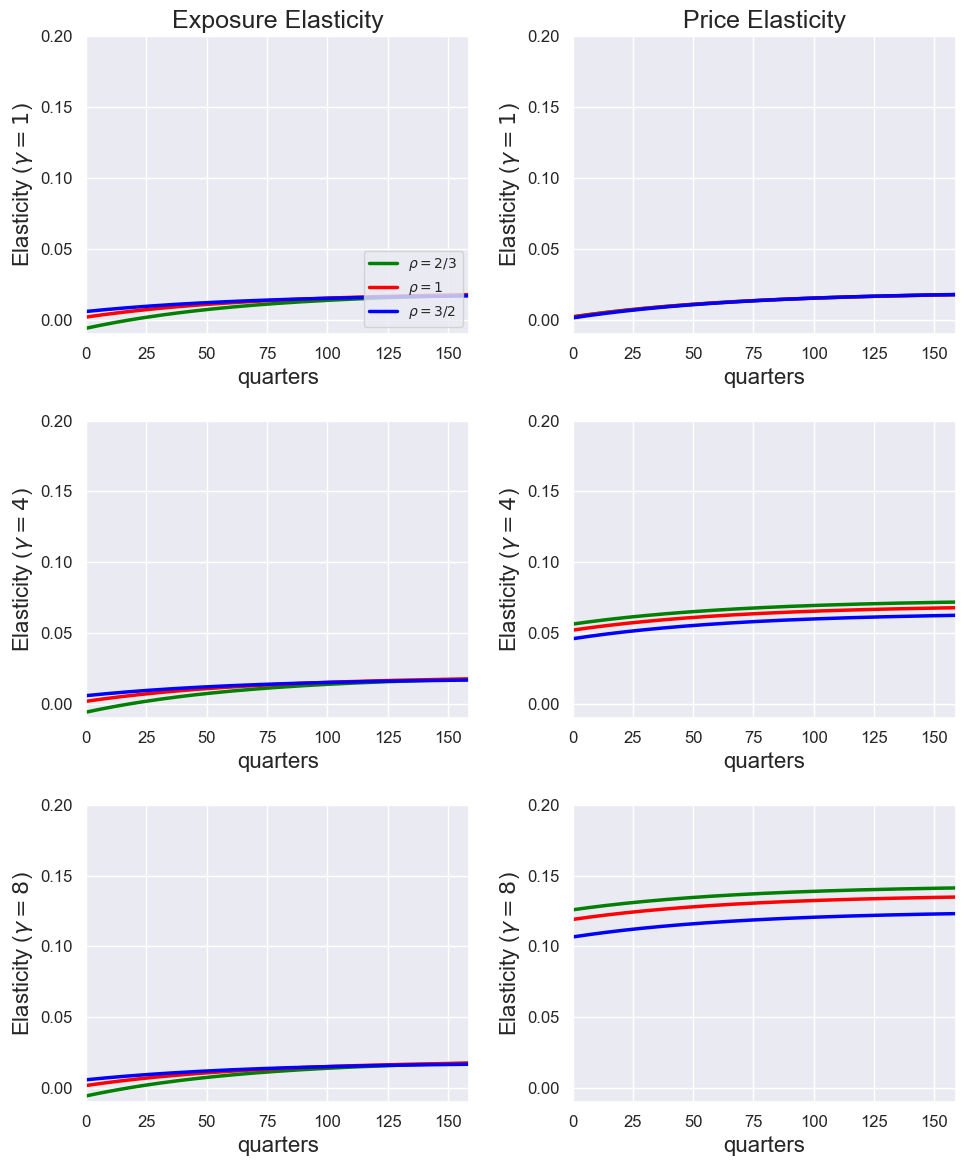

In [69]:
def plot_3x2_elasticity_grid_quarterly(models_dict, T=160, ylim_expo=None, ylim_price=None):
    """
    3x2 Grid Plot (Quarterly).
    Rows: Gamma = 1, Gamma = 4, Gamma = 8
    Cols: Exposure Elasticity, Price Elasticity
    """
    sns.set_style("darkgrid")
    
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']
    
    # --- CHANGED: Added 4.001 to the rows ---
    gammas_rows = [1.001, 4.001, 8.001]
    
    # --- CHANGED: 3 Rows, 2 Columns ---
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    
    # --- CHANGED: Time axis is just steps (Quarters) ---
    time_axis = np.arange(T)
    
    # Target Shock: Growth (Index 1)
    target_shock = 1
    
    for row_idx, g_val in enumerate(gammas_rows):
        for r_idx, r_val in enumerate(rhos_ordered):
            key = (g_val, r_val)
            
            if key in models_dict:
                mod = models_dict[key]
                color = colors[r_idx]
                label = labels[r_idx]
                
                # --- Exposure Elasticity (Column 0) ---
                # No scaling factor (Raw Quarterly)
                elas_expo = exposure_elasticity(
                    mod.gc_tp1, mod.X1_tp1, mod.X2_tp1, T, shock=target_shock, percentile=0.5
                ).flatten()
                
                sns.lineplot(
                    x=time_axis, y=elas_expo, ax=axes[row_idx, 0], color=color, label=label, linewidth=2.5
                )
                
                # --- Price Elasticity (Column 1) ---
                # Reconstruct SDF
                try:
                    p_names = list(mod.parameter_names.keys()) if isinstance(mod.parameter_names, dict) else mod.parameter_names
                    beta_val = mod.args[p_names.index('beta')]
                except:
                    beta_val = np.exp(-0.01 * 0.25)
                
                vmr_tp1 = mod.vmr1_tp1 + 0.5 * mod.vmr2_tp1
                logNtilde = mod.log_N_tilde
                log_SDF = np.log(beta_val) - r_val * mod.gc_tp1 + (r_val - 1) * vmr_tp1 + logNtilde
                
                # No scaling factor (Raw Quarterly)
                elas_price = price_elasticity(
                    mod.gc_tp1, log_SDF, mod.X1_tp1, mod.X2_tp1, T, shock=target_shock, percentile=0.5
                ).flatten()
                
                sns.lineplot(
                    x=time_axis, y=elas_price, ax=axes[row_idx, 1], color=color, label=label, linewidth=2.5
                )
            else:
                # Handle missing model (e.g. if you haven't solved for gamma=4 yet)
                # print(f"Missing model: {key}")
                pass

    # --- STYLING ---
    for ax in axes.flatten():
        ax.set_xlabel("quarters", fontsize=16)
        ax.tick_params(labelsize=12)
        ax.margins(x=0)
        
    # Column Titles (Only top row)
    axes[0, 0].set_title("Exposure Elasticity", fontsize=18)
    axes[0, 1].set_title("Price Elasticity", fontsize=18)
    
    # Row Labels (Gamma values)
    # Left Column
    axes[0, 0].set_ylabel(r"Elasticity ($\gamma=1$)", fontsize=16)
    axes[1, 0].set_ylabel(r"Elasticity ($\gamma=4$)", fontsize=16)
    axes[2, 0].set_ylabel(r"Elasticity ($\gamma=8$)", fontsize=16)
    
    # Right Column (Duplicate labels for clarity or keep empty)
    axes[0, 1].set_ylabel(r"Elasticity ($\gamma=1$)", fontsize=16)
    axes[1, 1].set_ylabel(r"Elasticity ($\gamma=4$)", fontsize=16)
    axes[2, 1].set_ylabel(r"Elasticity ($\gamma=8$)", fontsize=16)

    # Legends: Only keep Top-Left
    axes[0, 0].legend(fontsize=10, loc='lower right')
    
    # Remove all other legends
    for r in range(3):
        for c in range(2):
            if r == 0 and c == 0: continue
            if axes[r, c].get_legend(): axes[r, c].get_legend().remove()
    
    # Limits
    if ylim_expo:
        for r in range(3): axes[r, 0].set_ylim(ylim_expo)
    else:
        for r in range(3): axes[r, 0].set_ylim(bottom=0)
        
    if ylim_price:
        for r in range(3): axes[r, 1].set_ylim(ylim_price)
    else:
        for r in range(3): axes[r, 1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

# Note: Ensure you have solved for gamma=4.001 in your loop before running this!
plot_3x2_elasticity_grid_quarterly(
    stored_models_full, 
    T=160, 
    # Quarterly limits are usually smaller than annual. 
    # Adjust these based on your data range.
    ylim_expo=[-0.01, 0.2], 
    ylim_price=[-0.01, 0.2]
)

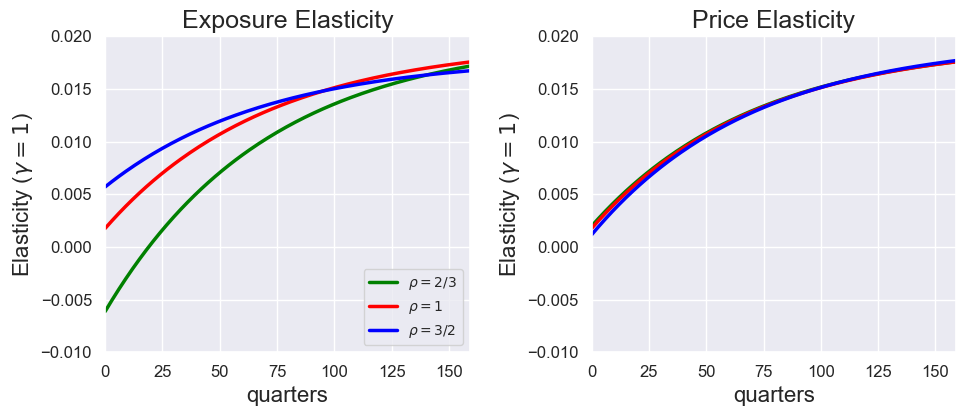

In [19]:
def plot_top_panel_elasticity(models_dict, T=160, ylim_expo=None, ylim_price=None):
    """
    Plots only the top row (Gamma = 1) for Exposure and Price Elasticity.
    1 Row x 2 Columns.
    """
    sns.set_style("darkgrid")
    
    rhos_ordered = [0.67, 1.001, 1.5]
    colors = ['green', 'red', 'blue']
    labels = [r'$\rho=2/3$', r'$\rho=1$', r'$\rho=3/2$']
    
    # Target Gamma for the top panel
    g_val = 1.001
    
    # 1 Row, 2 Columns
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    time_axis = np.arange(T)
    
    # Target Shock: Growth (Index 1)
    target_shock = 1
    
    for r_idx, r_val in enumerate(rhos_ordered):
        key = (g_val, r_val)
        
        if key in models_dict:
            mod = models_dict[key]
            color = colors[r_idx]
            label = labels[r_idx]
            
            # --- 1. Exposure Elasticity (Left Plot) ---
            elas_expo = exposure_elasticity(
                mod.gc_tp1, mod.X1_tp1, mod.X2_tp1, T, shock=target_shock, percentile=0.5
            ).flatten()
            
            sns.lineplot(
                x=time_axis, y=elas_expo, ax=axes[0], color=color, label=label, linewidth=2.5
            )
            
            # --- 2. Price Elasticity (Right Plot) ---
            # Reconstruct SDF parameters
            try:
                p_names = list(mod.parameter_names.keys()) if isinstance(mod.parameter_names, dict) else mod.parameter_names
                beta_val = mod.args[p_names.index('beta')]
            except:
                beta_val = np.exp(-0.01 * 0.25)
            
            vmr_tp1 = mod.vmr1_tp1 + 0.5 * mod.vmr2_tp1
            logNtilde = mod.log_N_tilde
            log_SDF = np.log(beta_val) - r_val * mod.gc_tp1 + (r_val - 1) * vmr_tp1 + logNtilde
            
            elas_price = price_elasticity(
                mod.gc_tp1, log_SDF, mod.X1_tp1, mod.X2_tp1, T, shock=target_shock, percentile=0.5
            ).flatten()
            
            sns.lineplot(
                x=time_axis, y=elas_price, ax=axes[1], color=color, label=label, linewidth=2.5
            )
        else:
            # print(f"Missing model: {key}")
            pass

    # --- STYLING ---
    for ax in axes:
        ax.set_xlabel("quarters", fontsize=16)
        ax.tick_params(labelsize=12)
        ax.margins(x=0)
        
    # Titles
    axes[0].set_title("Exposure Elasticity", fontsize=18)
    axes[1].set_title("Price Elasticity", fontsize=18)
    
    # Y-Labels
    axes[0].set_ylabel(r"Elasticity ($\gamma=1$)", fontsize=16)
    axes[1].set_ylabel(r"Elasticity ($\gamma=1$)", fontsize=16)

    # Legend (Left plot only)
    axes[0].legend(fontsize=10, loc='lower right')
    if axes[1].get_legend():
        axes[1].get_legend().remove()
    
    # Limits
    if ylim_expo:
        axes[0].set_ylim(ylim_expo)
    else:
        axes[0].set_ylim(bottom=0)
        
    if ylim_price:
        axes[1].set_ylim(ylim_price)
    else:
        axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EXECUTE
# =============================================================================

plot_top_panel_elasticity(
    stored_models_full, 
    T=160, 
    ylim_expo=[-0.01, 0.02], 
    ylim_price=[-0.01, 0.02]
)

<br>
<br>
<br>

# 3 Appendix

## 3.1.1 List of Outputs <a class="anchor" id="s3-1"></a>

We now examine the contents of `ModelSol`, which contains the attributes listed below. Each approximation is stored in a class `LinQuadVar`, which contains the coefficients for $X_{1,t}, X_{2,t}, X_{1,t}'X_{1,t}, W_{t+\epsilon}, W_{t+\epsilon}'W_{t+\epsilon}, X_{1,t}'W_{t+\epsilon}$ and the constant.


```{list-table}
* - Input
  - Type
  - Description
* - `JXn_t`
  - *LinQuadVar*
  - Approximation of jump and state variables at time $t$. Replace `n` with `0,1,2` to get the zeroth, first and second-order contribution. Omit `n` to get the full approximation. The variables are indexed in the order specified in Section 2. 
* - `Jn_t`
  - *LinQuadVar*
  - Same as `JXn_t` but limited to jump variables.
* - `Xn_tp1`
  - *LinQuadVar*
  - Same as `JXn_t` but limited to state variables.
* - `JXn_t_tilde`
  - *LinQuadVar*
  - Same as `JXn_t` but using distorted measure. This variation is also available for `Jn_t` and `Xn_tp1`.
* - `util_sol`
  - *dict*
  - Dictionary containing solutions of the continuation values, including $\mu^0, \Upsilon_0^2, \Upsilon_1^2,$ and $\Upsilon_2^2$ etc.
* - `vmrn_tp1`
  - *LinQuadVar*
  - Approximation of continuation values $\widehat{V}^1_{t+\epsilon}-\widehat{R}^1_t$ . Replace `n` with `0,1,2` to get the zeroth, first and second-order contribution. Omit `n` to get the full approximation. 
* - `gcn_tp1`
  - *LinQuadVar*
  - Approximation of consumption growth $\widehat{C}_{t+\epsilon}-\widehat{C}_t$ . Replace `n` with `0,1,2` to get the zeroth, first and second-order contribution. Omit `n` to get the full approximation. 
* - `ss`
  - *dict*
  - Steady states for state and jump variables
* - `log_N_tilde`
  - *LinQuadVar*
  - Approximation for the log change of measure
```
For example, we can obtain the coefficients for the first-order contribution of $\log{C_t/K_t}$ in the following way, noting that `cmk_t` was listed as the first jump variable when we specified the equilibrum conditions.


In [50]:
## Log consumption over capital approximation results, shown in the LinQuadVar coefficients form
ModelSol['JX1_t'][0].coeffs

{'c': array([[-0.00038372]]),
 'x': array([[ 0.        ,  0.00056165, -0.        ]])}

We can also display the full second-order approximation of $\log{C_t/K_t}$ using the `disp` function, which renders a `LinQuadVar` object in LATEX form.

In [51]:
## Log consumption over capital approximation results, shown in the Latex analytical form
disp(ModelSol['JX_t'][0],'\\log\\frac{C_t}{K_t}') 

<IPython.core.display.Math object>

Another example:

In [52]:
## Log capital growth process second order approximation results
disp(ModelSol['X2_tp1'][0],'\\log\\frac{K_{t+\epsilon}^2}{K_t^2}') 

<IPython.core.display.Math object>

<br>

## 3.1.2 Simulate Variables <a class="anchor" id="s3-3"></a>
Given a series of shock processes, we can simulate the path of our state and jump variables using the `ModelSolution.simulate` method. Here, we simulate 400 periods of i.i.d standard multivariate normal shocks.

In [53]:
n_J, n_X, n_W = ModelSol['var_shape']
Ws = np.random.multivariate_normal(np.zeros(n_W),np.eye(n_W),size = 400)
JX_sim = ModelSol.simulate(Ws)

<br>
<br>

# 3.2 Using `LinQuadVar` in Computation <a class="anchor" id="s2"></a>

In the previous section, we saw how to use `uncertain_expansion` to approximate variables and store their coefficients as `LinQuadVar` objects. In this section, we explore how to manipulate `LinQuadVar` objects for different uses.

To aid our examples, we first extract the steady states for the state evolution processes from the previous model solution:

See [src/lin_quad.py](https://github.com/lphansen/RiskUncertaintyValue/blob/main/src/lin_quad.py) for source code of `LinQuadVar` definition.

In [39]:
ModelSol['ss'][[0,1,2]]

array([-4.12667104,  0.07606349,  0.60576715])

In [40]:
n_J, n_X, n_W = ModelSol['var_shape']
print(n_J, n_X, n_W)
X0_tp1 = LinQuadVar({'c':np.array([[ModelSol['ss'][0]],[ModelSol['ss'][1]],[ModelSol['ss'][2]]])}, shape = (n_X, n_X, n_W))

5 3 3


## 3.2.1 `LinQuadVar` Operations <a class="anchor" id="s4-1"></a>
We can sum multiple LinQuads together in two different ways. Here we demonstrate this with an example by summing the zeroth, first and second order contributions of our approximation for capital growth. 

In [41]:
gk_tp1 = X0_tp1[0] + ModelSol['X1_tp1'][0]  + 0.5 * ModelSol['X2_tp1'][0] 
disp(gk_tp1,'\\log\\frac{K_{t+\epsilon}}{K_t}') 

<IPython.core.display.Math object>

In the next example, we sum together the contributions for both capital growth and technology:

In [42]:
lq_sum([X0_tp1, ModelSol['X1_tp1'], 0.5 * ModelSol['X2_tp1']]).coeffs

{'xx': array([[-0.     , -0.     , -0.     ,  0.     , -0.     ,  0.     ,  0.     ,  0.     , -0.     ],
        [ 0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ],
        [ 0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.02425]]),
 'c': array([[-4.12667958],
        [ 0.07606349],
        [ 0.5828862 ]]),
 'x2': array([[-0.       ,  0.0049993,  0.       ],
        [ 0.       ,  0.493    ,  0.       ],
        [ 0.       ,  0.       ,  0.47575  ]]),
 'x': array([[-0.        ,  0.00999859,  0.00000005],
        [ 0.        ,  0.986     ,  0.        ],
        [ 0.        ,  0.        ,  0.9515    ]]),
 'w': array([[0.00399962, 0.00173897, 0.        ],
        [0.        , 0.02478025, 0.        ],
        [0.        , 0.        , 0.21392032]]),
 'xw': array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.00199981,  0.00086948,  0.        ],
        [ 0.        ,  0.        ,  0.

## 3.2.2 `LinQuadVar` Split and Concat <a class="anchor" id="s4-2"></a>
`split` breaks multiple dimensional LinQuad into one-dimensional LinQuads, while `concat` does the inverse.

In [43]:
gk_tp1, Z_tp1, Y_tp1 = ModelSol['X1_tp1'].split()
concat([gk_tp1, Z_tp1, Y_tp1])

## 3.2.3 Evaluate a `LinQuadVar` <a class="anchor" id="s4-3"></a>
We can evaluate a LinQuad at specific state $(X_{t},W_{t+\epsilon})$ in time. As an example, we evaluate all 5 variables under steady state with a multivariate random normal shock.

In [44]:
x1 = np.zeros([n_X ,1])
x2 = np.zeros([n_X ,1])
x3 = np.zeros([n_X, 1])
w = np.random.multivariate_normal(np.zeros(n_W),np.eye(n_W),size = 1).T
ModelSol['JX_tp1'](*(x1,x2,w))

array([[ -4.12702496],
       [  0.0760692 ],
       [  0.60580901],
       [ -0.01751855],
       [  1.        ],
       [  0.0090725 ],
       [  0.05468477],
       [-12.14274156]])

## 3.2.4 Next period expression for `LinQuadVar` <a class="anchor" id="s4-4"></a>
`ModelSol` allows us to express a jump variable $J_t$ as a function of $t$ state and shock variables. Suppose we would like to compute its next period expression $J_{t+\epsilon}$ with shocks. The function `next_period` expresses $J_{t+\epsilon}$ in terms of $t$ state variables and $t+\epsilon$ shock variables. For example, we can express the $t+\epsilon$ expression for the first-order contribution to consumption over capital as:

In [45]:
ModelSol["X1_tp1"].coeffs

{'x': array([[-0.        ,  0.00999859, -0.        ],
        [-0.        ,  0.986     , -0.        ],
        [-0.        , -0.        ,  0.9515    ]]),
 'w': array([[ 0.00399962,  0.00173897, -0.        ],
        [-0.        ,  0.02478025, -0.        ],
        [-0.        , -0.        ,  0.21392032]]),
 'c': array([[0.00000096],
        [0.        ],
        [0.        ]])}

In [46]:
cmk1_tp1 = next_period(ModelSol['J1_t'][0], ModelSol['X1_tp1'])
disp(cmk1_tp1, '\\log\\frac{C_{t+\epsilon}^1}{K_{t+\epsilon}^1}') 

<IPython.core.display.Math object>

In [47]:
cmk2_tp1 = next_period(ModelSol['J2_t'][0], ModelSol['X1_tp1'], ModelSol['X2_tp1'])
disp(cmk2_tp1, '\\log\\frac{C_{t+\epsilon}^2}{K_{t+\epsilon}^2}') 

<IPython.core.display.Math object>

## 3.2.5 Compute the Expectation of time $t+\epsilon$ `LinQuadVar` <a class="anchor" id="s4-6"></a>

Suppose the distribution of shocks has a constant mean and variance (not state dependent). Then, we can use the `E` function to compute the expectation of a time $t+\epsilon$ `LinQuadVar` as follows:


In [48]:
E_w = ModelSol['util_sol']['μ_0']
cov_w = np.eye(n_W)
E_ww = cal_E_ww(E_w, cov_w)
E_cmk2_tp1 = E(cmk2_tp1, E_w, E_ww)
disp(E_cmk2_tp1, '\mathbb{E}[\\log\\frac{C_{t+\epsilon}^2}{K_{t+\epsilon}^2}|\mathfrak{F_t}]')

<IPython.core.display.Math object>

Suppose the distribution of shock has a state-dependent mean and variance (implied by $\tilde{N}_{t+\epsilon}$ shown in the notes), we can use `E_N_tp1` and `N_tilde_measure` to compute the expectation of time $t+\epsilon$ `LinQuadVar`.

In [ ]:
N_cm = N_tilde_measure(ModelSol['util_sol']['log_N_tilde'],(1,n_X,n_W))
E_cmk2_tp1_tilde = E_N_tp1(cmk2_tp1, N_cm)
disp(E_cmk2_tp1_tilde, '\mathbb{\\tilde{E}}[\\log\\frac{C_{t+\epsilon}^2}{K_{t+\epsilon}^2}|\mathfrak{F_t}]')

<IPython.core.display.Math object>